In [ ]:
# 초기버전
!pip install easyocr deepface opencv-python pandas numpy requests matplotlib pillow

import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image
import io
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import re
from collections import Counter
import json

class ThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True)

    def download_image(self, url):
        """URL에서 이미지 다운로드"""
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                return Image.open(io.BytesIO(response.content))
            return None
        except Exception as e:
            print(f"이미지 다운로드 실패: {e}")
            return None

    def calculate_brightness_contrast_saturation(self, image):
        """밝기, 대비, 채도 계산"""
        try:
            # PIL을 OpenCV 형식으로 변환
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # 그레이스케일로 변환하여 밝기 계산
            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)
            brightness = np.mean(gray)

            # 대비 계산 (표준편차 사용)
            contrast = np.std(gray)

            # HSV로 변환하여 채도 계산
            hsv = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2HSV)
            saturation = np.mean(hsv[:, :, 1])

            return {
                'brightness': round(brightness, 2),
                'contrast': round(contrast, 2),
                'saturation': round(saturation, 2)
            }
        except Exception as e:
            print(f"이미지 분석 실패: {e}")
            return {'brightness': 0, 'contrast': 0, 'saturation': 0}

    def extract_text_and_keywords(self, image):
        """텍스트 추출 및 키워드 분석"""
        try:
            # PIL을 numpy array로 변환
            img_array = np.array(image)

            # EasyOCR로 텍스트 추출
            results = self.reader.readtext(img_array)

            extracted_texts = []
            text_boxes = []

            for (bbox, text, confidence) in results:
                if confidence > 0.5:  # 신뢰도 50% 이상만 사용
                    extracted_texts.append(text)
                    text_boxes.append(bbox)

            # 모든 텍스트 결합
            full_text = ' '.join(extracted_texts)

            # 키워드 추출 (한글, 영문, 숫자)
            keywords = re.findall(r'[가-힣a-zA-Z0-9]+', full_text)
            keyword_freq = Counter(keywords)
            top_keywords = [word for word, count in keyword_freq.most_common(10)]

            return {
                'extracted_text': full_text,
                'keywords': top_keywords,
                'text_boxes': text_boxes,
                'text_count': len(extracted_texts)
            }
        except Exception as e:
            print(f"텍스트 추출 실패: {e}")
            return {
                'extracted_text': '',
                'keywords': [],
                'text_boxes': [],
                'text_count': 0
            }

    def calculate_text_ratio(self, image, text_boxes):
        """텍스트가 차지하는 비중 계산"""
        try:
            if not text_boxes:
                return 0

            image_area = image.width * image.height
            text_area = 0

            for bbox in text_boxes:
                # bbox는 4개의 점으로 구성된 사각형
                x_coords = [point[0] for point in bbox]
                y_coords = [point[1] for point in bbox]

                width = max(x_coords) - min(x_coords)
                height = max(y_coords) - min(y_coords)
                text_area += width * height

            text_ratio = (text_area / image_area) * 100
            return round(text_ratio, 2)
        except Exception as e:
            print(f"텍스트 비중 계산 실패: {e}")
            return 0

    def analyze_emotion(self, image):
        """얼굴 감정 분석"""
        try:
            # PIL을 numpy array로 변환
            img_array = np.array(image)

            # DeepFace로 감정 분석
            analysis = DeepFace.analyze(img_array, actions=['emotion'], enforce_detection=False)

            if isinstance(analysis, list):
                analysis = analysis[0]

            dominant_emotion = analysis['dominant_emotion']
            emotion_scores = analysis['emotion']

            return {
                'dominant_emotion': dominant_emotion,
                'emotion_scores': emotion_scores,
                'face_detected': True
            }
        except Exception as e:
            print(f"감정 분석 실패: {e}")
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': False
            }

    def analyze_thumbnail(self, url):
        """썸네일 종합 분석"""
        # 이미지 다운로드
        image = self.download_image(url)
        if image is None:
            return self.get_empty_result()

        # 각종 분석 수행
        visual_analysis = self.calculate_brightness_contrast_saturation(image)
        text_analysis = self.extract_text_and_keywords(image)
        text_ratio = self.calculate_text_ratio(image, text_analysis['text_boxes'])
        emotion_analysis = self.analyze_emotion(image)

        return {
            **visual_analysis,
            **text_analysis,
            'text_ratio': text_ratio,
            **emotion_analysis,
            'analysis_success': True
        }

    def get_empty_result(self):
        """분석 실패 시 기본값 반환"""
        return {
            'brightness': 0,
            'contrast': 0,
            'saturation': 0,
            'extracted_text': '',
            'keywords': [],
            'text_boxes': [],
            'text_count': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'analysis_success': False
        }

def main():
    # CSV 파일 읽기 (구글 드라이브에서 마운트하거나 업로드)
    from google.colab import files

    # 파일 업로드
    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]

    # CSV 읽기
    df = pd.read_csv(csv_filename)
    print(f"총 {len(df)}개의 데이터를 분석합니다.")

    # 분석기 초기화
    analyzer = ThumbnailAnalyzer()

    # 결과 저장을 위한 리스트
    results = []

    # 각 썸네일 분석
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
        thumbnail_url = row['썸네일URL']

        print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")

        # 썸네일 분석
        analysis_result = analyzer.analyze_thumbnail(thumbnail_url)

        # 원본 데이터와 분석 결과 결합
        result_row = {
            '수집일자': row.get('수집일자', ''),
            '게임명': row.get('게임명', ''),
            '영상ID': row.get('영상ID', ''),
            '영상제목': row.get('영상제목', ''),
            '썸네일URL': thumbnail_url,
            '조회수': row.get('viewCount', 0),
            '좋아요수': row.get('likeCount', 0),
            '댓글수': row.get('commentCount', 0),
            '밝기': analysis_result['brightness'],
            '대비': analysis_result['contrast'],
            '채도': analysis_result['saturation'],
            '추출된_텍스트': analysis_result['extracted_text'],
            '키워드': ', '.join(analysis_result['keywords']),
            '텍스트_개수': analysis_result['text_count'],
            '텍스트_비중': analysis_result['text_ratio'],
            '주요_감정': analysis_result['dominant_emotion'],
            '얼굴_감지여부': analysis_result['face_detected'],
            '분석_성공여부': analysis_result['analysis_success']
        }

        # 감정 점수들 추가
        for emotion, score in analysis_result['emotion_scores'].items():
            result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

        results.append(result_row)

        # 메모리 관리를 위해 주기적으로 정리
        if idx % 50 == 0:
            import gc
            gc.collect()

    # 결과를 DataFrame으로 변환
    result_df = pd.DataFrame(results)

    # 결과 CSV 저장
    output_filename = 'thumbnail_analysis_results.csv'
    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n분석 완료! 결과가 '{output_filename}'에 저장되었습니다.")

    # 기본 통계 출력
    print("\n=== 분석 결과 요약 ===")
    print(f"총 분석된 썸네일: {len(result_df)}")
    print(f"분석 성공: {result_df['분석_성공여부'].sum()}개")
    print(f"평균 밝기: {result_df['밝기'].mean():.2f}")
    print(f"평균 대비: {result_df['대비'].mean():.2f}")
    print(f"평균 채도: {result_df['채도'].mean():.2f}")
    print(f"평균 텍스트 비중: {result_df['텍스트_비중'].mean():.2f}%")
    print(f"얼굴 감지된 썸네일: {result_df['얼굴_감지여부'].sum()}개")

    # 주요 감정 분포
    emotion_counts = result_df['주요_감정'].value_counts()
    print(f"\n주요 감정 분포:")
    for emotion, count in emotion_counts.items():
        print(f"  {emotion}: {count}개")

    # 다운로드
    files.download(output_filename)

    return result_df

# 실행
if __name__ == "__main__":
    result_df = main()

IndexError: list index out of range

In [ ]:
# 초기버전 2
!pip install easyocr deepface opencv-python pandas numpy requests matplotlib pillow mtcnn

import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageDraw, ImageFont
import io
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import re
from collections import Counter
import json
import concurrent.futures
from threading import Lock
import gc

class EnhancedThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True)
        # Haar Cascade 얼굴 검출기 초기화
        try:
            self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        except:
            print("Haar Cascade 로드 실패, DeepFace만 사용합니다.")
            self.face_cascade = None

        self.lock = Lock()

    def download_image(self, url):
        """URL에서 이미지 다운로드"""
        try:
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
            }
            response = requests.get(url, timeout=15, headers=headers)
            if response.status_code == 200:
                return Image.open(io.BytesIO(response.content))
            return None
        except Exception as e:
            print(f"이미지 다운로드 실패: {e}")
            return None

    def preprocess_image_for_ocr(self, image):
        """OCR을 위한 이미지 전처리"""
        try:
            # PIL을 OpenCV 형식으로 변환
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # 그레이스케일 변환
            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)

            # 히스토그램 평활화로 대비 개선
            clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
            enhanced = clahe.apply(gray)

            # 가우시안 블러로 노이즈 제거
            denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)

            # 샤프닝 필터 적용
            kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
            sharpened = cv2.filter2D(denoised, -1, kernel)

            # 적응적 임계값으로 이진화
            binary = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)

            # 모폴로지 연산으로 텍스트 영역 정리
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
            cleaned = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

            return cleaned
        except Exception as e:
            print(f"이미지 전처리 실패: {e}")
            return cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)

    def expand_text_bbox(self, bbox, img_width, img_height, expand_ratio=0.15):
        """텍스트 바운딩 박스 확장"""
        try:
            x_coords = [point[0] for point in bbox]
            y_coords = [point[1] for point in bbox]

            min_x = int(min(x_coords))
            max_x = int(max(x_coords))
            min_y = int(min(y_coords))
            max_y = int(max(y_coords))

            # 확장 계산
            width = max_x - min_x
            height = max_y - min_y
            expand_x = int(width * expand_ratio)
            expand_y = int(height * expand_ratio)

            # 이미지 경계 내에서 확장
            expanded_min_x = max(0, min_x - expand_x)
            expanded_max_x = min(img_width, max_x + expand_x)
            expanded_min_y = max(0, min_y - expand_y)
            expanded_max_y = min(img_height, max_y + expand_y)

            return [[expanded_min_x, expanded_min_y], [expanded_max_x, expanded_min_y],
                    [expanded_max_x, expanded_max_y], [expanded_min_x, expanded_max_y]]
        except:
            return bbox

    def merge_nearby_boxes(self, text_boxes, merge_threshold=30):
        """근접한 텍스트 박스들을 병합"""
        if len(text_boxes) <= 1:
            return text_boxes

        merged_boxes = []
        used_indices = set()

        for i, box1 in enumerate(text_boxes):
            if i in used_indices:
                continue

            # 현재 박스와 병합할 박스들을 찾음
            boxes_to_merge = [box1]
            used_indices.add(i)

            x1_coords = [point[0] for point in box1]
            y1_coords = [point[1] for point in box1]
            center1_x = sum(x1_coords) / 4
            center1_y = sum(y1_coords) / 4

            for j, box2 in enumerate(text_boxes):
                if j in used_indices:
                    continue

                x2_coords = [point[0] for point in box2]
                y2_coords = [point[1] for point in box2]
                center2_x = sum(x2_coords) / 4
                center2_y = sum(y2_coords) / 4

                # 거리 계산
                distance = np.sqrt((center1_x - center2_x)**2 + (center1_y - center2_y)**2)

                if distance < merge_threshold:
                    boxes_to_merge.append(box2)
                    used_indices.add(j)

            # 병합된 박스의 경계 계산
            all_x = []
            all_y = []
            for box in boxes_to_merge:
                for point in box:
                    all_x.append(point[0])
                    all_y.append(point[1])

            merged_box = [[min(all_x), min(all_y)], [max(all_x), min(all_y)],
                         [max(all_x), max(all_y)], [min(all_x), max(all_y)]]
            merged_boxes.append(merged_box)

        return merged_boxes

    def extract_text_and_keywords(self, image):
        """개선된 텍스트 추출 및 키워드 분석"""
        try:
            # 원본 이미지
            img_array = np.array(image)

            # 전처리된 이미지
            preprocessed = self.preprocess_image_for_ocr(image)

            # 원본과 전처리된 이미지 모두에서 텍스트 추출
            results_original = self.reader.readtext(img_array, detail=1)
            results_preprocessed = self.reader.readtext(preprocessed, detail=1)

            # 결과 통합
            all_results = results_original + results_preprocessed

            extracted_texts = []
            text_boxes = []
            confidence_scores = []

            # 중복 제거 및 신뢰도 필터링
            seen_texts = set()
            for (bbox, text, confidence) in all_results:
                text_clean = re.sub(r'\s+', '', text.lower())
                if confidence > 0.3 and text_clean not in seen_texts and len(text.strip()) > 0:
                    extracted_texts.append(text)
                    # 박스 확장
                    expanded_bbox = self.expand_text_bbox(bbox, image.width, image.height)
                    text_boxes.append(expanded_bbox)
                    confidence_scores.append(confidence)
                    seen_texts.add(text_clean)

            # 근접한 박스들 병합
            merged_boxes = self.merge_nearby_boxes(text_boxes)

            # 모든 텍스트 결합
            full_text = ' '.join(extracted_texts)

            # 키워드 추출 (한글, 영문, 숫자)
            keywords = re.findall(r'[가-힣a-zA-Z0-9]+', full_text)
            # 길이가 1인 단어 제거
            keywords = [word for word in keywords if len(word) > 1]
            keyword_freq = Counter(keywords)
            top_keywords = [word for word, count in keyword_freq.most_common(15)]

            return {
                'extracted_text': full_text,
                'keywords': top_keywords,
                'text_boxes': merged_boxes,
                'text_count': len(extracted_texts),
                'avg_confidence': np.mean(confidence_scores) if confidence_scores else 0
            }
        except Exception as e:
            print(f"텍스트 추출 실패: {e}")
            return {
                'extracted_text': '',
                'keywords': [],
                'text_boxes': [],
                'text_count': 0,
                'avg_confidence': 0
            }

    def calculate_brightness_contrast_saturation(self, image):
        """밝기, 대비, 채도 계산"""
        try:
            # PIL을 OpenCV 형식으로 변환
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # 그레이스케일로 변환하여 밝기 계산
            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)
            brightness = np.mean(gray)

            # 대비 계산 (표준편차 사용)
            contrast = np.std(gray)

            # HSV로 변환하여 채도 계산
            hsv = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2HSV)
            saturation = np.mean(hsv[:, :, 1])

            # 추가 지표들
            # 히스토그램 분석
            hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
            hist_peak = np.argmax(hist)

            return {
                'brightness': round(brightness, 2),
                'contrast': round(contrast, 2),
                'saturation': round(saturation, 2),
                'hist_peak': int(hist_peak)
            }
        except Exception as e:
            print(f"이미지 분석 실패: {e}")
            return {'brightness': 0, 'contrast': 0, 'saturation': 0, 'hist_peak': 0}

    def calculate_text_ratio(self, image, text_boxes):
        """텍스트가 차지하는 비중 계산"""
        try:
            if not text_boxes:
                return 0

            image_area = image.width * image.height
            text_area = 0

            for bbox in text_boxes:
                # bbox는 4개의 점으로 구성된 사각형
                x_coords = [point[0] for point in bbox]
                y_coords = [point[1] for point in bbox]

                width = max(x_coords) - min(x_coords)
                height = max(y_coords) - min(y_coords)
                text_area += width * height

            text_ratio = (text_area / image_area) * 100
            return round(text_ratio, 2)
        except Exception as e:
            print(f"텍스트 비중 계산 실패: {e}")
            return 0

    def detect_faces_multiple_methods(self, image):
        """다중 방법으로 얼굴 검출"""
        img_array = np.array(image)
        faces = []

        # 방법 1: Haar Cascade
        if self.face_cascade is not None:
            try:
                gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
                haar_faces = self.face_cascade.detectMultiScale(
                    gray, scaleFactor=1.1, minNeighbors=3, minSize=(30, 30)
                )
                for (x, y, w, h) in haar_faces:
                    faces.append({'x': x, 'y': y, 'w': w, 'h': h, 'method': 'haar'})
            except:
                pass

        # 방법 2: DeepFace with different backends
        for backend in ['opencv', 'mtcnn', 'retinaface']:
            try:
                analysis = DeepFace.analyze(
                    img_array,
                    actions=['emotion'],
                    detector_backend=backend,
                    enforce_detection=False
                )
                if isinstance(analysis, list):
                    for face in analysis:
                        region = face.get('region', {})
                        if region:
                            faces.append({
                                'x': region.get('x', 0),
                                'y': region.get('y', 0),
                                'w': region.get('w', 0),
                                'h': region.get('h', 0),
                                'method': backend,
                                'emotion': face.get('dominant_emotion', 'unknown'),
                                'emotion_scores': face.get('emotion', {})
                            })
                else:
                    region = analysis.get('region', {})
                    if region:
                        faces.append({
                            'x': region.get('x', 0),
                            'y': region.get('y', 0),
                            'w': region.get('w', 0),
                            'h': region.get('h', 0),
                            'method': backend,
                            'emotion': analysis.get('dominant_emotion', 'unknown'),
                            'emotion_scores': analysis.get('emotion', {})
                        })
                break  # 성공하면 다른 backend 시도하지 않음
            except:
                continue

        return faces

    def analyze_emotion(self, image):
        """개선된 얼굴 감정 분석"""
        try:
            faces = self.detect_faces_multiple_methods(image)

            if not faces:
                return {
                    'dominant_emotion': 'unknown',
                    'emotion_scores': {},
                    'face_detected': False,
                    'face_count': 0
                }

            # 가장 큰 얼굴 선택
            largest_face = max(faces, key=lambda x: x['w'] * x['h'])

            # 감정 정보가 있는 경우 사용
            if 'emotion' in largest_face:
                return {
                    'dominant_emotion': largest_face['emotion'],
                    'emotion_scores': largest_face['emotion_scores'],
                    'face_detected': True,
                    'face_count': len(faces),
                    'face_area_ratio': round((largest_face['w'] * largest_face['h']) / (image.width * image.height) * 100, 2)
                }

            # 감정 정보가 없는 경우 별도 분석
            img_array = np.array(image)
            x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']

            # 얼굴 영역 확장 (10%)
            expand = 0.1
            x_exp = max(0, int(x - w * expand))
            y_exp = max(0, int(y - h * expand))
            w_exp = min(image.width - x_exp, int(w * (1 + 2 * expand)))
            h_exp = min(image.height - y_exp, int(h * (1 + 2 * expand)))

            face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]

            analysis = DeepFace.analyze(face_region, actions=['emotion'], enforce_detection=False)
            if isinstance(analysis, list):
                analysis = analysis[0]

            return {
                'dominant_emotion': analysis['dominant_emotion'],
                'emotion_scores': analysis['emotion'],
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }

        except Exception as e:
            print(f"감정 분석 실패: {e}")
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': False,
                'face_count': 0,
                'face_area_ratio': 0
            }

    def create_debug_image(self, image, text_boxes, faces):
        """디버그용 박스 표시 이미지 생성"""
        try:
            debug_img = image.copy()
            draw = ImageDraw.Draw(debug_img)

            # 텍스트 박스 그리기 (빨간색)
            for bbox in text_boxes:
                points = [(point[0], point[1]) for point in bbox]
                draw.polygon(points, outline='red', width=2)

            # 얼굴 박스 그리기 (파란색)
            for face in faces:
                x, y, w, h = face['x'], face['y'], face['w'], face['h']
                draw.rectangle([x, y, x+w, y+h], outline='blue', width=3)

            return debug_img
        except:
            return image

    def analyze_thumbnail(self, url, save_debug=False):
        """썸네일 종합 분석"""
        # 이미지 다운로드
        image = self.download_image(url)
        if image is None:
            return self.get_empty_result()

        try:
            # 각종 분석 수행
            visual_analysis = self.calculate_brightness_contrast_saturation(image)
            text_analysis = self.extract_text_and_keywords(image)
            text_ratio = self.calculate_text_ratio(image, text_analysis['text_boxes'])
            emotion_analysis = self.analyze_emotion(image)

            # 디버그 이미지 생성 (옵션)
            debug_image_path = None
            if save_debug:
                faces = self.detect_faces_multiple_methods(image)
                debug_img = self.create_debug_image(image, text_analysis['text_boxes'], faces)
                debug_image_path = f"debug_{hash(url) % 10000}.jpg"
                debug_img.save(debug_image_path)

            return {
                **visual_analysis,
                **text_analysis,
                'text_ratio': text_ratio,
                **emotion_analysis,
                'analysis_success': True,
                'debug_image_path': debug_image_path
            }
        except Exception as e:
            print(f"분석 중 오류 발생: {e}")
            return self.get_empty_result()

    def get_empty_result(self):
        """분석 실패 시 기본값 반환"""
        return {
            'brightness': 0,
            'contrast': 0,
            'saturation': 0,
            'hist_peak': 0,
            'extracted_text': '',
            'keywords': [],
            'text_boxes': [],
            'text_count': 0,
            'avg_confidence': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False,
            'debug_image_path': None
        }

def main():
    # CSV 파일 읽기 (구글 드라이브에서 마운트하거나 업로드)
    from google.colab import files

    # 파일 업로드
    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]

    # CSV 읽기
    df = pd.read_csv(csv_filename)
    print(f"총 {len(df)}개의 데이터를 분석합니다.")

    # 분석기 초기화
    analyzer = EnhancedThumbnailAnalyzer()

    # 결과 저장을 위한 리스트
    results = []

    # 각 썸네일 분석
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
        thumbnail_url = row['썸네일URL']

        print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")

        # 썸네일 분석 (처음 5개는 디버그 이미지 저장)
        save_debug = idx < 5
        analysis_result = analyzer.analyze_thumbnail(thumbnail_url, save_debug=save_debug)

        # 원본 데이터와 분석 결과 결합
        result_row = {
            '수집일자': row.get('수집일자', ''),
            '게임명': row.get('게임명', ''),
            '영상ID': row.get('영상ID', ''),
            '영상제목': row.get('영상제목', ''),
            '썸네일URL': thumbnail_url,
            '조회수': row.get('viewCount', 0),
            '좋아요수': row.get('likeCount', 0),
            '댓글수': row.get('commentCount', 0),
            '밝기': analysis_result['brightness'],
            '대비': analysis_result['contrast'],
            '채도': analysis_result['saturation'],
            '히스토그램_피크': analysis_result['hist_peak'],
            '추출된_텍스트': analysis_result['extracted_text'],
            '키워드': ', '.join(analysis_result['keywords']),
            '텍스트_개수': analysis_result['text_count'],
            '텍스트_신뢰도': analysis_result['avg_confidence'],
            '텍스트_비중': analysis_result['text_ratio'],
            '주요_감정': analysis_result['dominant_emotion'],
            '얼굴_감지여부': analysis_result['face_detected'],
            '얼굴_개수': analysis_result['face_count'],
            '얼굴_비중': analysis_result['face_area_ratio'],
            '분석_성공여부': analysis_result['analysis_success']
        }

        # 감정 점수들 추가
        for emotion, score in analysis_result['emotion_scores'].items():
            result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

        results.append(result_row)

        # 메모리 관리를 위해 주기적으로 정리
        if idx % 20 == 0:
            gc.collect()

    # 결과를 DataFrame으로 변환
    result_df = pd.DataFrame(results)

    # 결과 CSV 저장
    output_filename = 'enhanced_thumbnail_analysis_results.csv'
    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n분석 완료! 결과가 '{output_filename}'에 저장되었습니다.")

    # 기본 통계 출력
    print("\n=== 개선된 분석 결과 요약 ===")
    print(f"총 분석된 썸네일: {len(result_df)}")
    print(f"분석 성공: {result_df['분석_성공여부'].sum()}개")
    print(f"평균 밝기: {result_df['밝기'].mean():.2f}")
    print(f"평균 대비: {result_df['대비'].mean():.2f}")
    print(f"평균 채도: {result_df['채도'].mean():.2f}")
    print(f"평균 텍스트 비중: {result_df['텍스트_비중'].mean():.2f}%")
    print(f"평균 텍스트 신뢰도: {result_df['텍스트_신뢰도'].mean():.2f}")
    print(f"얼굴 감지된 썸네일: {result_df['얼굴_감지여부'].sum()}개")
    print(f"평균 얼굴 비중: {result_df['얼굴_비중'].mean():.2f}%")

    # 주요 감정 분포
    emotion_counts = result_df['주요_감정'].value_counts()
    print(f"\n주요 감정 분포:")
    for emotion, count in emotion_counts.items():
        print(f"  {emotion}: {count}개")

    # 키워드 분석
    all_keywords = []
    for keywords_str in result_df['키워드']:
        if keywords_str:
            all_keywords.extend(keywords_str.split(', '))

    keyword_freq = Counter(all_keywords)
    print(f"\n상위 키워드:")
    for keyword, count in keyword_freq.most_common(10):
        print(f"  {keyword}: {count}회")

    # 다운로드
    files.download(output_filename)

    return result_df

# 실행
if __name__ == "__main__":
    result_df = main()


ERROR: Operation cancelled by user


ModuleNotFoundError: No module named 'easyocr'

In [ ]:
# 썸네일분석 텍스트 완성도가 높음 0528, 썸네일 박스처리 발표자료용
!pip install easyocr deepface opencv-python pandas numpy requests matplotlib pillow mtcnn scikit-image

import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageDraw, ImageFont, ImageEnhance
import io
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import re
from collections import Counter
import json
import concurrent.futures
from threading import Lock
import gc
from skimage import filters, morphology, measure
from scipy import ndimage

class ThumbnailAnalyzer:
    def __init__(self):
        # 다중 언어 및 GPU 설정으로 EasyOCR 초기화
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)

        # Haar Cascade 얼굴 검출기 초기화
        try:
            self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        except:
            print("Haar Cascade 로드 실패, DeepFace만 사용합니다.")
            self.face_cascade = None

        self.lock = Lock()

    def download_image(self, url):
        """URL에서 이미지 다운로드"""
        try:
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
            }
            response = requests.get(url, timeout=15, headers=headers)
            if response.status_code == 200:
                return Image.open(io.BytesIO(response.content))
            return None
        except Exception as e:
            print(f"이미지 다운로드 실패: {e}")
            return None

    def advanced_image_preprocessing(self, image):
        """고급 이미지 전처리 - 텍스트 인식률 극대화"""
        try:
            # PIL을 OpenCV 형식으로 변환
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # 1. 이미지 크기 조정 (DPI 300 기준으로 최적화)
            height, width = opencv_image.shape[:2]
            if width < 1200:  # 작은 이미지는 확대
                scale_factor = 1200 / width
                new_width = int(width * scale_factor)
                new_height = int(height * scale_factor)
                opencv_image = cv2.resize(opencv_image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

            # 2. 그레이스케일 변환
            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)

            # 3. 노이즈 제거 (가우시안 블러)
            denoised = cv2.GaussianBlur(gray, (3, 3), 0)

            # 4. 히스토그램 평활화 (CLAHE)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(denoised)

            # 5. 샤프닝 필터 적용
            kernel_sharpening = np.array([[-1,-1,-1],
                                        [-1, 9,-1],
                                        [-1,-1,-1]])
            sharpened = cv2.filter2D(enhanced, -1, kernel_sharpening)

            # 6. 적응적 임계값 처리 (여러 방법 시도)
            binary_methods = []

            # 방법 1: 적응적 가우시안 임계값
            binary1 = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
            binary_methods.append(binary1)

            # 방법 2: 적응적 평균 임계값
            binary2 = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY, 15, 3)
            binary_methods.append(binary2)

            # 방법 3: Otsu 임계값
            _, binary3 = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            binary_methods.append(binary3)

            # 방법 4: 반전된 이미지 (어두운 배경의 밝은 글자용)
            inverted = cv2.bitwise_not(sharpened)
            _, binary4 = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            binary_methods.append(binary4)

            # 7. 모폴로지 연산으로 텍스트 영역 정리
            processed_images = []
            for binary in binary_methods:
                # 닫힘 연산 (작은 구멍 메우기)
                kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
                closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close)

                # 열림 연산 (노이즈 제거)
                kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
                opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)

                processed_images.append(opened)

            return processed_images + [sharpened]  # 원본 그레이스케일도 포함

        except Exception as e:
            print(f"이미지 전처리 실패: {e}")
            return [cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)]

    def extract_text_with_multiple_methods(self, image):
        """다중 방법으로 텍스트 추출"""
        try:
            # 원본 이미지
            img_array = np.array(image)

            # 전처리된 이미지들
            processed_images = self.advanced_image_preprocessing(image)

            all_results = []
            confidence_threshold = 0.2  # 낮은 임계값으로 더 많은 텍스트 수집

            # 원본 이미지에서 추출
            try:
                results_original = self.reader.readtext(img_array, detail=1,
                                                      width_ths=0.5, height_ths=0.5)
                all_results.extend(results_original)
            except:
                pass

            # 전처리된 이미지들에서 추출
            for i, processed_img in enumerate(processed_images):
                try:
                    # EasyOCR 파라미터 조정으로 더 세밀한 검출
                    results = self.reader.readtext(processed_img, detail=1,
                                                 width_ths=0.3,    # 더 작은 텍스트 박스 허용
                                                 height_ths=0.3,   # 더 작은 텍스트 박스 허용
                                                 paragraph=False,   # 단어별 분리
                                                 slope_ths=0.3,    # 기울어진 텍스트 허용
                                                 ycenter_ths=0.7,  # 수직 정렬 완화
                                                 mag_ratio=1.5)    # 확대 비율
                    all_results.extend(results)
                except Exception as e:
                    print(f"전처리 이미지 {i} OCR 실패: {e}")
                    continue

            # 결과 통합 및 중복 제거
            extracted_texts = []
            text_boxes = []
            confidence_scores = []

            # 텍스트 정규화 함수
            def normalize_text(text):
                return re.sub(r'[^\w가-힣]', '', text.lower().strip())

            seen_texts = set()
            for (bbox, text, confidence) in all_results:
                text_clean = text.strip()
                text_normalized = normalize_text(text_clean)

                # 필터링 조건
                if (confidence > confidence_threshold and
                    len(text_clean) > 0 and
                    len(text_normalized) > 0 and
                    text_normalized not in seen_texts):

                    extracted_texts.append(text_clean)
                    # 박스 확장
                    expanded_bbox = self.expand_text_bbox(bbox, image.width, image.height, 0.2)
                    text_boxes.append(expanded_bbox)
                    confidence_scores.append(confidence)
                    seen_texts.add(text_normalized)

            # 근접한 박스들 병합
            merged_boxes = self.merge_nearby_boxes(text_boxes, merge_threshold=50)

            # 모든 텍스트 결합
            full_text = ' '.join(extracted_texts)

            # 키워드 추출 개선
            keywords = self.extract_advanced_keywords(full_text)

            return {
                'extracted_text': full_text,
                'keywords': keywords,
                'text_boxes': merged_boxes,
                'text_count': len(extracted_texts),
                'avg_confidence': np.mean(confidence_scores) if confidence_scores else 0,
                'total_detections': len(all_results)
            }

        except Exception as e:
            print(f"텍스트 추출 실패: {e}")
            return {
                'extracted_text': '',
                'keywords': [],
                'text_boxes': [],
                'text_count': 0,
                'avg_confidence': 0,
                'total_detections': 0
            }

    def extract_advanced_keywords(self, text):
        """고급 키워드 추출"""
        try:
            # 한글, 영문, 숫자 추출
            words = re.findall(r'[가-힣a-zA-Z0-9]+', text)

            # 길이 필터링 (1글자 제외, 너무 긴 것도 제외)
            filtered_words = [word for word in words if 1 < len(word) < 20]

            # 빈도 계산
            word_freq = Counter(filtered_words)

            # 상위 키워드 추출
            top_keywords = [word for word, count in word_freq.most_common(20)]

            return top_keywords
        except:
            return []

    def expand_text_bbox(self, bbox, img_width, img_height, expand_ratio=0.2):
        """텍스트 바운딩 박스 확장 개선"""
        try:
            x_coords = [point[0] for point in bbox]
            y_coords = [point[1] for point in bbox]

            min_x = int(min(x_coords))
            max_x = int(max(x_coords))
            min_y = int(min(y_coords))
            max_y = int(max(y_coords))

            # 확장 계산
            width = max_x - min_x
            height = max_y - min_y
            expand_x = int(width * expand_ratio)
            expand_y = int(height * expand_ratio)

            # 이미지 경계 내에서 확장
            expanded_min_x = max(0, min_x - expand_x)
            expanded_max_x = min(img_width, max_x + expand_x)
            expanded_min_y = max(0, min_y - expand_y)
            expanded_max_y = min(img_height, max_y + expand_y)

            return [[expanded_min_x, expanded_min_y], [expanded_max_x, expanded_min_y],
                    [expanded_max_x, expanded_max_y], [expanded_min_x, expanded_max_y]]
        except:
            return bbox

    def merge_nearby_boxes(self, text_boxes, merge_threshold=40):
        """근접한 텍스트 박스들을 병합 개선"""
        if len(text_boxes) <= 1:
            return text_boxes

        merged_boxes = []
        used_indices = set()

        for i, box1 in enumerate(text_boxes):
            if i in used_indices:
                continue

            # 현재 박스와 병합할 박스들을 찾음
            boxes_to_merge = [box1]
            used_indices.add(i)

            x1_coords = [point[0] for point in box1]
            y1_coords = [point[1] for point in box1]
            center1_x = sum(x1_coords) / 4
            center1_y = sum(y1_coords) / 4

            for j, box2 in enumerate(text_boxes):
                if j in used_indices:
                    continue

                x2_coords = [point[0] for point in box2]
                y2_coords = [point[1] for point in box2]
                center2_x = sum(x2_coords) / 4
                center2_y = sum(y2_coords) / 4

                # 거리 계산 (유클리드 거리)
                distance = np.sqrt((center1_x - center2_x)**2 + (center1_y - center2_y)**2)

                # 수평/수직 정렬도 고려
                horizontal_overlap = (abs(center1_y - center2_y) < merge_threshold * 0.5)
                vertical_overlap = (abs(center1_x - center2_x) < merge_threshold * 0.5)

                if distance < merge_threshold or horizontal_overlap or vertical_overlap:
                    boxes_to_merge.append(box2)
                    used_indices.add(j)

            # 병합된 박스의 경계 계산
            all_x = []
            all_y = []
            for box in boxes_to_merge:
                for point in box:
                    all_x.append(point[0])
                    all_y.append(point[1])

            merged_box = [[min(all_x), min(all_y)], [max(all_x), min(all_y)],
                         [max(all_x), max(all_y)], [min(all_x), max(all_y)]]
            merged_boxes.append(merged_box)

        return merged_boxes

    def calculate_brightness_contrast_saturation(self, image):
        """밝기, 대비, 채도 계산"""
        try:
            # PIL을 OpenCV 형식으로 변환
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            # 그레이스케일로 변환하여 밝기 계산
            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)
            brightness = np.mean(gray)

            # 대비 계산 (표준편차 사용)
            contrast = np.std(gray)

            # HSV로 변환하여 채도 계산
            hsv = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2HSV)
            saturation = np.mean(hsv[:, :, 1])

            # 추가 지표들
            # 히스토그램 분석
            hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
            hist_peak = np.argmax(hist)

            # 엔트로피 계산 (이미지 복잡도)
            entropy = -np.sum(hist * np.log2(hist + 1e-7))

            return {
                'brightness': round(brightness, 2),
                'contrast': round(contrast, 2),
                'saturation': round(saturation, 2),
                'hist_peak': int(hist_peak),
                'entropy': round(entropy, 2)
            }
        except Exception as e:
            print(f"이미지 분석 실패: {e}")
            return {'brightness': 0, 'contrast': 0, 'saturation': 0, 'hist_peak': 0, 'entropy': 0}

    def calculate_text_ratio(self, image, text_boxes):
        """텍스트가 차지하는 비중 계산"""
        try:
            if not text_boxes:
                return 0

            image_area = image.width * image.height
            text_area = 0

            for bbox in text_boxes:
                # bbox는 4개의 점으로 구성된 사각형
                x_coords = [point[0] for point in bbox]
                y_coords = [point[1] for point in bbox]

                width = max(x_coords) - min(x_coords)
                height = max(y_coords) - min(y_coords)
                text_area += width * height

            text_ratio = (text_area / image_area) * 100
            return round(text_ratio, 2)
        except Exception as e:
            print(f"텍스트 비중 계산 실패: {e}")
            return 0

    def detect_faces_multiple_methods(self, image):
        """다중 방법으로 얼굴 검출"""
        img_array = np.array(image)
        faces = []

        # 방법 1: Haar Cascade
        if self.face_cascade is not None:
            try:
                gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
                haar_faces = self.face_cascade.detectMultiScale(
                    gray, scaleFactor=1.05, minNeighbors=3, minSize=(20, 20)
                )
                for (x, y, w, h) in haar_faces:
                    faces.append({'x': x, 'y': y, 'w': w, 'h': h, 'method': 'haar'})
            except:
                pass

        # 방법 2: DeepFace with different backends
        for backend in ['opencv', 'mtcnn', 'retinaface']:
            try:
                analysis = DeepFace.analyze(
                    img_array,
                    actions=['emotion'],
                    detector_backend=backend,
                    enforce_detection=False
                )
                if isinstance(analysis, list):
                    for face in analysis:
                        region = face.get('region', {})
                        if region:
                            faces.append({
                                'x': region.get('x', 0),
                                'y': region.get('y', 0),
                                'w': region.get('w', 0),
                                'h': region.get('h', 0),
                                'method': backend,
                                'emotion': face.get('dominant_emotion', 'unknown'),
                                'emotion_scores': face.get('emotion', {})
                            })
                else:
                    region = analysis.get('region', {})
                    if region:
                        faces.append({
                            'x': region.get('x', 0),
                            'y': region.get('y', 0),
                            'w': region.get('w', 0),
                            'h': region.get('h', 0),
                            'method': backend,
                            'emotion': analysis.get('dominant_emotion', 'unknown'),
                            'emotion_scores': analysis.get('emotion', {})
                        })
                break  # 성공하면 다른 backend 시도하지 않음
            except:
                continue

        return faces

    def analyze_emotion(self, image):
        """개선된 얼굴 감정 분석"""
        try:
            faces = self.detect_faces_multiple_methods(image)

            if not faces:
                return {
                    'dominant_emotion': 'unknown',
                    'emotion_scores': {},
                    'face_detected': False,
                    'face_count': 0,
                    'face_area_ratio': 0
                }

            # 가장 큰 얼굴 선택
            largest_face = max(faces, key=lambda x: x['w'] * x['h'])

            # 감정 정보가 있는 경우 사용
            if 'emotion' in largest_face:
                return {
                    'dominant_emotion': largest_face['emotion'],
                    'emotion_scores': largest_face['emotion_scores'],
                    'face_detected': True,
                    'face_count': len(faces),
                    'face_area_ratio': round((largest_face['w'] * largest_face['h']) / (image.width * image.height) * 100, 2)
                }

            # 감정 정보가 없는 경우 별도 분석
            img_array = np.array(image)
            x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']

            # 얼굴 영역 확장 (15%)
            expand = 0.15
            x_exp = max(0, int(x - w * expand))
            y_exp = max(0, int(y - h * expand))
            w_exp = min(image.width - x_exp, int(w * (1 + 2 * expand)))
            h_exp = min(image.height - y_exp, int(h * (1 + 2 * expand)))

            face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]

            analysis = DeepFace.analyze(face_region, actions=['emotion'], enforce_detection=False)
            if isinstance(analysis, list):
                analysis = analysis[0]

            return {
                'dominant_emotion': analysis['dominant_emotion'],
                'emotion_scores': analysis['emotion'],
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }

        except Exception as e:
            print(f"감정 분석 실패: {e}")
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': False,
                'face_count': 0,
                'face_area_ratio': 0
            }

    def create_debug_image(self, image, text_boxes, faces):
        """디버그용 박스 표시 이미지 생성"""
        try:
            debug_img = image.copy()
            draw = ImageDraw.Draw(debug_img)

            # 텍스트 박스 그리기 (빨간색)
            for bbox in text_boxes:
                points = [(point[0], point[1]) for point in bbox]
                draw.polygon(points, outline='red', width=3)

            # 얼굴 박스 그리기 (파란색)
            for face in faces:
                x, y, w, h = face['x'], face['y'], face['w'], face['h']
                draw.rectangle([x, y, x+w, y+h], outline='blue', width=4)

            return debug_img
        except:
            return image

    def analyze_thumbnail(self, url, save_debug=False):
        """썸네일 종합 분석"""
        # 이미지 다운로드
        image = self.download_image(url)
        if image is None:
            return self.get_empty_result()

        try:
            # 각종 분석 수행
            visual_analysis = self.calculate_brightness_contrast_saturation(image)
            text_analysis = self.extract_text_with_multiple_methods(image)
            text_ratio = self.calculate_text_ratio(image, text_analysis['text_boxes'])
            emotion_analysis = self.analyze_emotion(image)

            # 디버그 이미지 생성 (옵션)
            debug_image_path = None
            if save_debug:
                faces = self.detect_faces_multiple_methods(image)
                debug_img = self.create_debug_image(image, text_analysis['text_boxes'], faces)
                debug_image_path = f"debug_{hash(url) % 10000}.jpg"
                debug_img.save(debug_image_path)

            return {
                **visual_analysis,
                **text_analysis,
                'text_ratio': text_ratio,
                **emotion_analysis,
                'analysis_success': True,
                'debug_image_path': debug_image_path
            }
        except Exception as e:
            print(f"분석 중 오류 발생: {e}")
            return self.get_empty_result()

    def get_empty_result(self):
        """분석 실패 시 기본값 반환"""
        return {
            'brightness': 0,
            'contrast': 0,
            'saturation': 0,
            'hist_peak': 0,
            'entropy': 0,
            'extracted_text': '',
            'keywords': [],
            'text_boxes': [],
            'text_count': 0,
            'avg_confidence': 0,
            'total_detections': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False,
            'debug_image_path': None
        }

def main():
    # CSV 파일 읽기 (구글 드라이브에서 마운트하거나 업로드)
    from google.colab import files

    # 파일 업로드
    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]

    # CSV 읽기
    df = pd.read_csv(csv_filename)
    print(f"총 {len(df)}개의 데이터를 분석합니다.")

    # 분석기 초기화
    analyzer = ThumbnailAnalyzer()

    # 결과 저장을 위한 리스트
    results = []

    # 각 썸네일 분석
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
        thumbnail_url = row['썸네일URL']

        print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")

        # 썸네일 분석 (처음 5개는 디버그 이미지 저장)
        save_debug = idx < 5
        analysis_result = analyzer.analyze_thumbnail(thumbnail_url, save_debug=save_debug)

        # 원본 데이터와 분석 결과 결합
        result_row = {
            '수집일자': row.get('수집일자', ''),
            '게임명': row.get('게임명', ''),
            '영상ID': row.get('영상ID', ''),
            '영상제목': row.get('영상제목', ''),
            '썸네일URL': thumbnail_url,
            '조회수': row.get('viewCount', 0),
            '좋아요수': row.get('likeCount', 0),
            '댓글수': row.get('commentCount', 0),
            '밝기': analysis_result['brightness'],
            '대비': analysis_result['contrast'],
            '채도': analysis_result['saturation'],
            '히스토그램_피크': analysis_result['hist_peak'],
            '엔트로피': analysis_result['entropy'],
            '추출된_텍스트': analysis_result['extracted_text'],
            '키워드': ', '.join(analysis_result['keywords']),
            '텍스트_개수': analysis_result['text_count'],
            '텍스트_신뢰도': analysis_result['avg_confidence'],
            '총_검출수': analysis_result['total_detections'],
            '텍스트_비중': analysis_result['text_ratio'],
            '주요_감정': analysis_result['dominant_emotion'],
            '얼굴_감지여부': analysis_result['face_detected'],
            '얼굴_개수': analysis_result['face_count'],
            '얼굴_비중': analysis_result['face_area_ratio'],
            '분석_성공여부': analysis_result['analysis_success']
        }

        # 감정 점수들 추가
        for emotion, score in analysis_result['emotion_scores'].items():
            result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

        results.append(result_row)

        # 메모리 관리를 위해 주기적으로 정리
        if idx % 15 == 0:
            gc.collect()

    # 결과를 DataFrame으로 변환
    result_df = pd.DataFrame(results)

    # 결과 CSV 저장
    output_filename = 'thumbnail_analysis_results.csv'
    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n분석 완료! 결과가 '{output_filename}'에 저장되었습니다.")

    # 기본 통계 출력
    print(f"총 분석된 썸네일: {len(result_df)}")
    print(f"분석 성공: {result_df['분석_성공여부'].sum()}개")
    print(f"평균 밝기: {result_df['밝기'].mean():.2f}")
    print(f"평균 대비: {result_df['대비'].mean():.2f}")
    print(f"평균 채도: {result_df['채도'].mean():.2f}")
    print(f"평균 텍스트 비중: {result_df['텍스트_비중'].mean():.2f}%")
    print(f"평균 텍스트 신뢰도: {result_df['텍스트_신뢰도'].mean():.2f}")
    print(f"평균 총 검출수: {result_df['총_검출수'].mean():.1f}")
    print(f"얼굴 감지된 썸네일: {result_df['얼굴_감지여부'].sum()}개")
    print(f"평균 얼굴 비중: {result_df['얼굴_비중'].mean():.2f}%")

    # 주요 감정 분포
    emotion_counts = result_df['주요_감정'].value_counts()
    print(f"\n주요 감정 분포:")
    for emotion, count in emotion_counts.items():
        print(f"  {emotion}: {count}개")

    # 키워드 분석
    all_keywords = []
    for keywords_str in result_df['키워드']:
        if keywords_str:
            all_keywords.extend(keywords_str.split(', '))

    keyword_freq = Counter(all_keywords)
    print(f"\n상위 키워드:")
    for keyword, count in keyword_freq.most_common(15):
        print(f"  {keyword}: {count}회")

    # 다운로드
    files.download(output_filename)

    return result_df

# 실행
if __name__ == "__main__":
    result_df = main()


IndexError: list index out of range

In [ ]:
# csv배포용 0602, (나중에 csv수집하고 변수 삭제 및 수정 해야함, 쓸모없는 컬럼이나 0이 많음)
!pip install easyocr deepface opencv-python pandas numpy requests matplotlib pillow mtcnn scikit-image

import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageDraw, ImageFont, ImageEnhance
import io
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import re
from collections import Counter
import json
import concurrent.futures
from threading import Lock
import gc
from skimage import filters, morphology, measure
from scipy import ndimage

class ThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)
        try:
            self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        except:
            self.face_cascade = None
        self.lock = Lock()

    def download_image(self, url):
        """URL에서 이미지 다운로드"""
        try:
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
            }
            response = requests.get(url, timeout=15, headers=headers)
            if response.status_code == 200:
                return Image.open(io.BytesIO(response.content))
            return None
        except Exception as e:
            print(f"이미지 다운로드 실패: {e}")
            return None

    def advanced_image_preprocessing(self, image):
        """고급 이미지 전처리 - 텍스트 인식률 극대화"""
        try:
            opencv_image = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

            height, width = opencv_image.shape[:2]
            if width < 1200:
                scale_factor = 1200 / width
                new_width = int(width * scale_factor)
                new_height = int(height * scale_factor)
                opencv_image = cv2.resize(opencv_image, (new_width, new_height), interpolation=cv2.INTER_CUBIC)

            gray = cv2.cvtColor(opencv_image, cv2.COLOR_BGR2GRAY)
            denoised = cv2.GaussianBlur(gray, (3, 3), 0)

            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            enhanced = clahe.apply(denoised)

            kernel_sharpening = np.array([[-1,-1,-1],
                                        [-1, 9,-1],
                                        [-1,-1,-1]])
            sharpened = cv2.filter2D(enhanced, -1, kernel_sharpening)

            binary_methods = []
            binary1 = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                          cv2.THRESH_BINARY, 11, 2)
            binary_methods.append(binary1)

            binary2 = cv2.adaptiveThreshold(sharpened, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY, 15, 3)
            binary_methods.append(binary2)

            _, binary3 = cv2.threshold(sharpened, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            binary_methods.append(binary3)

            inverted = cv2.bitwise_not(sharpened)
            _, binary4 = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            binary_methods.append(binary4)

            processed_images = []
            for binary in binary_methods:
                kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
                closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel_close)

                kernel_open = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
                opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open)
                processed_images.append(opened)

            return processed_images + [sharpened]
        except Exception as e:
            print(f"이미지 전처리 실패: {e}")
            return [cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)]

    def extract_text_with_multiple_methods(self, image):
        """다중 방법으로 텍스트 추출"""
        try:
            img_array = np.array(image)
            processed_images = self.advanced_image_preprocessing(image)

            all_results = []
            confidence_threshold = 0.2

            try:
                results_original = self.reader.readtext(img_array, detail=1,
                                                      width_ths=0.5, height_ths=0.5)
                all_results.extend(results_original)
            except:
                pass

            for i, processed_img in enumerate(processed_images):
                try:
                    results = self.reader.readtext(processed_img, detail=1,
                                                 width_ths=0.3,
                                                 height_ths=0.3,
                                                 paragraph=False,
                                                 slope_ths=0.3,
                                                 ycenter_ths=0.7,
                                                 mag_ratio=1.5)
                    all_results.extend(results)
                except Exception as e:
                    print(f"전처리 이미지 {i} OCR 실패: {e}")
                    continue

            extracted_texts = []
            text_boxes = []
            confidence_scores = []

            def normalize_text(text):
                return re.sub(r'[^\w가-힣]', '', text.lower().strip())

            seen_texts = set()
            for (bbox, text, confidence) in all_results:
                text_clean = text.strip()
                text_normalized = normalize_text(text_clean)

                if (confidence > confidence_threshold and
                    len(text_clean) > 0 and
                    len(text_normalized) > 0 and
                    text_normalized not in seen_texts):

                    extracted_texts.append(text_clean)
                    expanded_bbox = self.expand_text_bbox(bbox, image.width, image.height, 0.2)
                    text_boxes.append(expanded_bbox)
                    confidence_scores.append(confidence)
                    seen_texts.add(text_normalized)

            merged_boxes = self.merge_nearby_boxes(text_boxes, merge_threshold=50)

            full_text = ' '.join(extracted_texts)
            keywords = self.extract_advanced_keywords(full_text)

            return {
                'extracted_text': full_text,
                'keywords': keywords,
                'text_boxes': merged_boxes,
                'text_count': len(extracted_texts),
                'avg_confidence': np.mean(confidence_scores) if confidence_scores else 0,
                'total_detections': len(all_results)
            }
        except Exception as e:
            print(f"텍스트 추출 실패: {e}")
            return {
                'extracted_text': '',
                'keywords': [],
                'text_boxes': [],
                'text_count': 0,
                'avg_confidence': 0,
                'total_detections': 0
            }

    def extract_advanced_keywords(self, text):
        """고급 키워드 추출"""
        try:
            words = re.findall(r'[가-힣a-zA-Z0-9]+', text)
            filtered_words = [word for word in words if 1 < len(word) < 20]
            word_freq = Counter(filtered_words)
            top_keywords = [word for word, count in word_freq.most_common(20)]
            return top_keywords
        except:
            return []

    def expand_text_bbox(self, bbox, img_width, img_height, expand_ratio=0.2):
        """텍스트 바운딩 박스 확장 개선"""
        try:
            x_coords = [point[0] for point in bbox]
            y_coords = [point[1] for point in bbox]

            min_x = int(min(x_coords))
            max_x = int(max(x_coords))
            min_y = int(min(y_coords))
            max_y = int(max(y_coords))

            width = max_x - min_x
            height = max_y - min_y
            expand_x = int(width * expand_ratio)
            expand_y = int(height * expand_ratio)

            expanded_min_x = max(0, min_x - expand_x)
            expanded_max_x = min(img_width, max_x + expand_x)
            expanded_min_y = max(0, min_y - expand_y)
            expanded_max_y = min(img_height, max_y + expand_y)

            return [[expanded_min_x, expanded_min_y], [expanded_max_x, expanded_min_y],
                    [expanded_max_x, expanded_max_y], [expanded_min_x, expanded_max_y]]
        except:
            return bbox

    def merge_nearby_boxes(self, text_boxes, merge_threshold=40):
        """근접한 텍스트 박스들을 병합 개선"""
        if len(text_boxes) <= 1:
            return text_boxes

        merged_boxes = []
        used_indices = set()

        for i, box1 in enumerate(text_boxes):
            if i in used_indices:
                continue

            boxes_to_merge = [box1]
            used_indices.add(i)

            x1_coords = [point[0] for point in box1]
            y1_coords = [point[1] for point in box1]
            center1_x = sum(x1_coords) / 4
            center1_y = sum(y1_coords) / 4

            for j, box2 in enumerate(text_boxes):
                if j in used_indices:
                    continue

                x2_coords = [point[0] for point in box2]
                y2_coords = [point[1] for point in box2]
                center2_x = sum(x2_coords) / 4
                center2_y = sum(y2_coords) / 4

                distance = np.sqrt((center1_x - center2_x)**2 + (center1_y - center2_y)**2)

                horizontal_overlap = (abs(center1_y - center2_y) < merge_threshold * 0.5)
                vertical_overlap = (abs(center1_x - center2_x) < merge_threshold * 0.5)

                if distance < merge_threshold or horizontal_overlap or vertical_overlap:
                    boxes_to_merge.append(box2)
                    used_indices.add(j)

            all_x = []
            all_y = []
            for box in boxes_to_merge:
                for point in box:
                    all_x.append(point[0])
                    all_y.append(point[1])

            merged_box = [[min(all_x), min(all_y)], [max(all_x), min(all_y)],
                         [max(all_x), max(all_y)], [min(all_x), max(all_y)]]
            merged_boxes.append(merged_box)

        return merged_boxes

    def calculate_text_ratio(self, image, text_boxes):
        """텍스트가 차지하는 비중 계산"""
        try:
            if not text_boxes:
                return 0

            image_area = image.width * image.height
            text_area = 0

            for bbox in text_boxes:
                x_coords = [point[0] for point in bbox]
                y_coords = [point[1] for point in bbox]

                width = max(x_coords) - min(x_coords)
                height = max(y_coords) - min(y_coords)
                text_area += width * height

            text_ratio = (text_area / image_area) * 100
            return round(text_ratio, 2)
        except Exception as e:
            print(f"텍스트 비중 계산 실패: {e}")
            return 0

    def detect_faces_multiple_methods(self, image):
        """다중 방법으로 얼굴 검출"""
        img_array = np.array(image)
        faces = []

        if self.face_cascade is not None:
            try:
                gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
                haar_faces = self.face_cascade.detectMultiScale(
                    gray, scaleFactor=1.05, minNeighbors=3, minSize=(20, 20)
                )
                for (x, y, w, h) in haar_faces:
                    faces.append({'x': x, 'y': y, 'w': w, 'h': h, 'method': 'haar'})
            except:
                pass

        for backend in ['opencv', 'mtcnn', 'retinaface']:
            try:
                analysis = DeepFace.analyze(
                    img_array,
                    actions=['emotion'],
                    detector_backend=backend,
                    enforce_detection=False
                )
                if isinstance(analysis, list):
                    for face in analysis:
                        region = face.get('region', {})
                        if region:
                            faces.append({
                                'x': region.get('x', 0),
                                'y': region.get('y', 0),
                                'w': region.get('w', 0),
                                'h': region.get('h', 0),
                                'method': backend,
                                'emotion': face.get('dominant_emotion', 'unknown'),
                                'emotion_scores': face.get('emotion', {})
                            })
                else:
                    region = analysis.get('region', {})
                    if region:
                        faces.append({
                            'x': region.get('x', 0),
                            'y': region.get('y', 0),
                            'w': region.get('w', 0),
                            'h': region.get('h', 0),
                            'method': backend,
                            'emotion': analysis.get('dominant_emotion', 'unknown'),
                            'emotion_scores': analysis.get('emotion', {})
                        })
                break
            except:
                continue

        return faces

    def analyze_emotion(self, image):
        """개선된 얼굴 감정 분석"""
        try:
            faces = self.detect_faces_multiple_methods(image)

            if not faces:
                return {
                    'dominant_emotion': 'unknown',
                    'emotion_scores': {},
                    'face_detected': False,
                    'face_count': 0,
                    'face_area_ratio': 0
                }

            largest_face = max(faces, key=lambda x: x['w'] * x['h'])

            if 'emotion' in largest_face:
                return {
                    'dominant_emotion': largest_face['emotion'],
                    'emotion_scores': largest_face['emotion_scores'],
                    'face_detected': True,
                    'face_count': len(faces),
                    'face_area_ratio': round((largest_face['w'] * largest_face['h']) / (image.width * image.height) * 100, 2)
                }

            img_array = np.array(image)
            x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']
            expand = 0.15
            x_exp = max(0, int(x - w * expand))
            y_exp = max(0, int(y - h * expand))
            w_exp = min(image.width - x_exp, int(w * (1 + 2 * expand)))
            h_exp = min(image.height - y_exp, int(h * (1 + 2 * expand)))

            face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]

            analysis = DeepFace.analyze(face_region, actions=['emotion'], enforce_detection=False)
            if isinstance(analysis, list):
                analysis = analysis[0]

            return {
                'dominant_emotion': analysis['dominant_emotion'],
                'emotion_scores': analysis['emotion'],
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }

        except Exception as e:
            print(f"감정 분석 실패: {e}")
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': False,
                'face_count': 0,
                'face_area_ratio': 0
            }

    def create_debug_image(self, image, text_boxes, faces):
        """디버그용 박스 표시 이미지 생성"""
        try:
            debug_img = image.copy()
            draw = ImageDraw.Draw(debug_img)

            for bbox in text_boxes:
                points = [(point[0], point[1]) for point in bbox]
                draw.polygon(points, outline='red', width=3)

            for face in faces:
                x, y, w, h = face['x'], face['y'], face['w'], face['h']
                draw.rectangle([x, y, x+w, y+h], outline='blue', width=4)

            return debug_img
        except:
            return image

    def analyze_thumbnail(self, url, save_debug=False):
        """썸네일 종합 분석"""
        image = self.download_image(url)
        if image is None:
            return self.get_empty_result()

        try:
            text_analysis = self.extract_text_with_multiple_methods(image)
            text_ratio = self.calculate_text_ratio(image, text_analysis['text_boxes'])
            emotion_analysis = self.analyze_emotion(image)

            debug_image_path = None
            if save_debug:
                faces = self.detect_faces_multiple_methods(image)
                debug_img = self.create_debug_image(image, text_analysis['text_boxes'], faces)
                debug_image_path = f"debug_{hash(url) % 10000}.jpg"
                debug_img.save(debug_image_path)

            return {
                **text_analysis,
                'text_ratio': text_ratio,
                **emotion_analysis,
                'analysis_success': True,
                'debug_image_path': debug_image_path
            }
        except Exception as e:
            print(f"분석 중 오류 발생: {e}")
            return self.get_empty_result()

    def get_empty_result(self):
        """분석 실패 시 기본값 반환"""
        return {
            'extracted_text': '',
            'keywords': [],
            'text_boxes': [],
            'text_count': 0,
            'avg_confidence': 0,
            'total_detections': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False,
            'debug_image_path': None
        }

def main():
    from google.colab import files

    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]

    df = pd.read_csv(csv_filename)
    print(f"총 {len(df)}개의 데이터를 분석합니다.")

    analyzer = ThumbnailAnalyzer()

    results = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
        thumbnail_url = row['썸네일URL']

        print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")

        save_debug = idx < 5
        analysis_result = analyzer.analyze_thumbnail(thumbnail_url, save_debug=save_debug)

        result_row = {
            '수집일자': row.get('수집일자', ''),
            '게임명': row.get('게임명', ''),
            '영상ID': row.get('영상ID', ''),
            '영상제목': row.get('영상제목', ''),
            '썸네일URL': thumbnail_url,
            '조회수': row.get('viewCount', 0),
            '좋아요수': row.get('likeCount', 0),
            '댓글수': row.get('commentCount', 0),
            '추출된_텍스트': analysis_result['extracted_text'],
            '키워드': ', '.join(analysis_result['keywords']),
            '텍스트_개수': analysis_result['text_count'],
            '텍스트_신뢰도': analysis_result['avg_confidence'],
            '총_검출수': analysis_result['total_detections'],
            '텍스트_비중': analysis_result['text_ratio'],
            '주요_감정': analysis_result['dominant_emotion'],
            '얼굴_감지여부': analysis_result['face_detected'],
            '얼굴_개수': analysis_result['face_count'],
            '얼굴_비중': analysis_result['face_area_ratio'],
            '분석_성공여부': analysis_result['analysis_success']
        }

        for emotion, score in analysis_result['emotion_scores'].items():
            result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

        results.append(result_row)

        if idx % 15 == 0:
            gc.collect()

    result_df = pd.DataFrame(results)
    output_filename = 'thumbnail_analysis_results.csv'
    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\n분석 완료! 결과가 '{output_filename}'에 저장되었습니다.")

    print(f"총 분석된 썸네일: {len(result_df)}")
    print(f"분석 성공: {result_df['분석_성공여부'].sum()}개")
    print(f"평균 텍스트 비중: {result_df['텍스트_비중'].mean():.2f}%")
    print(f"평균 텍스트 신뢰도: {result_df['텍스트_신뢰도'].mean():.2f}")
    print(f"평균 총 검출수: {result_df['총_검출수'].mean():.1f}")
    print(f"얼굴 감지된 썸네일: {result_df['얼굴_감지여부'].sum()}개")
    print(f"평균 얼굴 비중: {result_df['얼굴_비중'].mean():.2f}%")

    emotion_counts = result_df['주요_감정'].value_counts()
    print(f"\n주요 감정 분포:")
    for emotion, count in emotion_counts.items():
        print(f"  {emotion}: {count}개")

    all_keywords = []
    for keywords_str in result_df['키워드']:
        if keywords_str:
            all_keywords.extend(keywords_str.split(', '))

    keyword_freq = Counter(all_keywords)
    print(f"\n상위 키워드:")
    for keyword, count in keyword_freq.most_common(15):
        print(f"  {keyword}: {count}회")

    files.download(output_filename)

    return result_df

if __name__ == "__main__":
    result_df = main()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━

Saving game_api_data_test_250201.csv to game_api_data_test_250201.csv
총 64개의 데이터를 분석합니다.


썸네일 분석 중:   0%|          | 0/64 [00:00<?, ?it/s]


분석 중 (1/64): T1 vs GEN | 매치 23 하이라이트 | 02.01 | 2025 LCK CUP 그룹 배틀
25-06-03 01:34:07 - facial_expression_model_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 147MB/s]


...

감정 분석 실패: Exception encountered when calling layer 'conv2d' (type Conv2D).

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2D] name: 

Call arguments received by layer 'conv2d' (type Conv2D):
  • inputs=tf.Tensor(shape=(1, 48, 48, 1), dtype=float32)

분석 중 (64/64): "예술" |  TLN vs. NS  | 9일차 MATCH 1 H/L 02.02 | VCT 퍼시픽 킥오프 2025


썸네일 분석 중: 100%|██████████| 64/64 [04:52<00:00,  4.57s/it]

감정 분석 실패: Exception encountered when calling layer 'conv2d' (type Conv2D).

{{function_node __wrapped__Conv2D_device_/job:localhost/replica:0/task:0/device:GPU:0}} No DNN in stream executor. [Op:Conv2D] name: 

Call arguments received by layer 'conv2d' (type Conv2D):
  • inputs=tf.Tensor(shape=(1, 48, 48, 1), dtype=float32)

분석 완료! 결과가 'thumbnail_analysis_results.csv'에 저장되었습니다.
총 분석된 썸네일: 64
분석 성공: 64개
평균 텍스트 비중: 157.02%
평균 텍스트 신뢰도: 0.47
평균 총 검출수: 43.6
얼굴 감지된 썸네일: 0개
평균 얼굴 비중: 0.00%

주요 감정 분포:
  unknown: 64개

상위 키워드:
  02: 5회
  VS: 3회
  TDP: 3회
  II: 3회
  MATCH: 3회
  Ia: 2회
  풀영상: 2회
  V5: 2회
  15: 2회
  11: 2회
  OD: 2회
  100: 2회
  47: 2회
  i다: 2회
  CI: 2회


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 안해봄
import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageDraw, ImageFont, ImageEnhance
import io
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import warnings
import os
from tqdm import tqdm
import re
from collections import Counter
import json
import concurrent.futures
from threading import Lock
import gc
from skimage import filters, morphology, measure
from scipy import ndimage

# ... [기존 ThumbnailAnalyzer 클래스 코드 동일] ...

def main():
    from google.colab import files

    # 1. 기존 결과 파일 로드 및 처리 완료 ID 추출
    def load_existing_results():
        try:
            existing_df = pd.read_csv('thumbnail_analysis_results.csv')
            processed_ids = set(existing_df['영상ID'])
            print(f"기존 {len(existing_df)}개 결과 로드")
            return existing_df, processed_ids
        except FileNotFoundError:
            return pd.DataFrame(), set()

    existing_df, processed_ids = load_existing_results()

    # 2. CSV 파일 업로드 및 미처리 데이터 필터링
    uploaded = files.upload()
    csv_filename = list(uploaded.keys())[0]
    df = pd.read_csv(csv_filename)
    df = df[~df['영상ID'].isin(processed_ids)]
    print(f"총 {len(df)}개 미처리 데이터 분석 시작")

    # 3. 분석기 초기화 및 결과 저장 설정
    analyzer = ThumbnailAnalyzer()
    results = []
    batch_size = 15  # 15개 단위로 중간 저장
    temp_filename = 'thumbnail_analysis_results.tmp'

    try:
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
            # 이미 처리된 항목 건너뛰기
            if row['영상ID'] in processed_ids:
                continue

            # 4. 썸네일 분석 실행
            thumbnail_url = row['썸네일URL']
            print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")
            save_debug = idx < 5
            analysis_result = analyzer.analyze_thumbnail(thumbnail_url, save_debug=save_debug)

            # 5. 결과 데이터 생성
            result_row = {
                '수집일자': row.get('수집일자', ''),
                '게임명': row.get('게임명', ''),
                '영상ID': row['영상ID'],
                '영상제목': row.get('영상제목', ''),
                '썸네일URL': thumbnail_url,
                '조회수': row.get('viewCount', 0),
                '좋아요수': row.get('likeCount', 0),
                '댓글수': row.get('commentCount', 0),
                '추출된_텍스트': analysis_result['extracted_text'],
                '키워드': ', '.join(analysis_result['keywords']),
                '텍스트_개수': analysis_result['text_count'],
                '텍스트_신뢰도': analysis_result['avg_confidence'],
                '총_검출수': analysis_result['total_detections'],
                '텍스트_비중': analysis_result['text_ratio'],
                '주요_감정': analysis_result['dominant_emotion'],
                '얼굴_감지여부': analysis_result['face_detected'],
                '얼굴_개수': analysis_result['face_count'],
                '얼굴_비중': analysis_result['face_area_ratio'],
                '분석_성공여부': analysis_result['analysis_success']
            }

            # 감정 점수 추가
            for emotion, score in analysis_result['emotion_scores'].items():
                result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

            results.append(result_row)

            # 6. 배치 단위로 중간 저장
            if len(results) % batch_size == 0 and len(results) > 0:
                try:
                    # 임시 파일에 저장
                    batch_df = pd.DataFrame(results)
                    batch_df.to_csv(temp_filename, index=False, encoding='utf-8-sig')

                    # 원본 파일과 병합
                    combined_df = pd.concat([existing_df, batch_df])
                    combined_df.to_csv('thumbnail_analysis_results.csv', index=False, encoding='utf-8-sig')

                    # 처리 완료 ID 업데이트
                    processed_ids.update(batch_df['영상ID'])
                    results = []
                except Exception as e:
                    print(f"중간 저장 실패: {e}")
                    results = []  # 실패 시 현재 배치 초기화

            # 메모리 관리
            if idx % 15 == 0:
                gc.collect()

        # 7. 최종 남은 결과 저장
        if results:
            try:
                batch_df = pd.DataFrame(results)
                batch_df.to_csv(temp_filename, index=False, encoding='utf-8-sig')
                combined_df = pd.concat([existing_df, batch_df])
                combined_df.to_csv('thumbnail_analysis_results.csv', index=False, encoding='utf-8-sig')
                processed_ids.update(batch_df['영상ID'])
            except Exception as e:
                print(f"최종 저장 실패: {e}")

    finally:
        # 8. 강제 종료 시에도 최종 저장
        if results:
            try:
                batch_df = pd.DataFrame(results)
                batch_df.to_csv(temp_filename, index=False, encoding='utf-8-sig')
                combined_df = pd.concat([existing_df, batch_df])
                combined_df.to_csv('thumbnail_analysis_results.csv', index=False, encoding='utf-8-sig')
            except Exception as e:
                print(f"예외 발생 후 최종 저장: {e}")

    # 9. 최종 결과 출력 및 다운로드
    final_df = pd.read_csv('thumbnail_analysis_results.csv')
    print(f"\n분석 완료! 결과가 'thumbnail_analysis_results.csv'에 저장되었습니다.")
    print(f"총 분석된 썸네일: {len(final_df)}")
    print(f"분석 성공: {final_df['분석_성공여부'].sum()}개")
    print(f"평균 텍스트 비중: {final_df['텍스트_비중'].mean():.2f}%")
    print(f"평균 텍스트 신뢰도: {final_df['텍스트_신뢰도'].mean():.2f}")
    print(f"평균 총 검출수: {final_df['총_검출수'].mean():.1f}")
    print(f"얼굴 감지된 썸네일: {final_df['얼굴_감지여부'].sum()}개")
    print(f"평균 얼굴 비중: {final_df['얼굴_비중'].mean():.2f}%")

    # 감정 분포 분석
    emotion_counts = final_df['주요_감정'].value_counts()
    print(f"\n주요 감정 분포:")
    for emotion, count in emotion_counts.items():
        print(f"  {emotion}: {count}개")

    # 상위 키워드 분석
    all_keywords = []
    for keywords_str in final_df['키워드']:
        if keywords_str:
            all_keywords.extend(keywords_str.split(', '))
    keyword_freq = Counter(all_keywords)
    print(f"\n상위 키워드:")
    for keyword, count in keyword_freq.most_common(15):
        print(f"  {keyword}: {count}회")

    # 결과 파일 다운로드
    files.download('thumbnail_analysis_results.csv')
    return final_df

if __name__ == "__main__":
    result_df = main()


KeyboardInterrupt: 

In [ ]:
# 필수 라이브러리 설치 (Colab 전용)
!pip install --upgrade tensorflow[and-cuda]==2.15.0
# CUDA 11.8 및 cuDNN 8.9.4 재설치
!apt-get install -y cuda-toolkit-11-8
!pip install nvidia-cudnn-cu11==8.9.4.25
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/x86_64-linux-gnu:/usr/local/cuda-11.8/lib64'


# GPU 메모리 관리 초기화
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# 나머지 라이브러리 임포트
import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageDraw, ImageFont, ImageEnhance, ImageFilter
import io
import easyocr
from deepface import DeepFace
from tqdm import tqdm
import re
from collections import Counter
import gc
from skimage import filters, morphology, measure
from scipy import ndimage
import warnings
from threading import Lock # ?
warnings.filterwarnings('ignore')

# GPU 호환성 개선 클래스
class EnhancedThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        self.lock = Lock()
        self.emotion_model = self._init_emotion_model()

    def _init_emotion_model(self):
        try:
            return DeepFace.build_model("Facenet")
        except Exception as e:
            print(f"감정 분석 모델 초기화 실패: {e}")
            return None

    def detect_faces_multiple_methods(self, image):
        """다중 얼굴 감지 방법 통합"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        # 방법 1: Haar Cascade
        faces_haar = self.face_cascade.detectMultiScale(gray, 1.1, 4)

        # 방법 2: DeepFace RetinaFace
        try:
            faces_retina = DeepFace.extract_faces(img_array, detector_backend='retinaface', enforce_detection=False)
            faces_retina = [face['facial_area'] for face in faces_retina if face['confidence'] > 0.9]
        except:
            faces_retina = []

        # 결과 통합
        combined = []
        for x,y,w,h in faces_haar:
            combined.append({'x':x, 'y':y, 'w':w, 'h':h, 'method':'haar'})
        for face in faces_retina:
            combined.append({
                'x': face['x'],
                'y': face['y'],
                'w': face['w'],
                'h': face['h'],
                'method': 'retinaface'
            })

        return combined

    def preprocess_image(self, image):
        """이미지 전처리 강화"""
        # 조명 보정
        enhancer = ImageEnhance.Contrast(image)
        image = enhancer.enhance(1.5)

        # 샤프닝
        image = image.filter(ImageFilter.UnsharpMask(radius=2, percent=150))
        return image

    def analyze_thumbnail(self, url, save_debug=False):
        """썸네일 분석 메인 함수"""
        result = {
            'extracted_text': '',
            'keywords': [],
            'text_count': 0,
            'avg_confidence': 0,
            'total_detections': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False
        }

        try:
            # 이미지 다운로드
            response = requests.get(url, timeout=10)
            image = Image.open(io.BytesIO(response.content))
            image = self.preprocess_image(image)

            # 텍스트 추출
            text_results = self.reader.readtext(np.array(image), detail=1)
            if text_results:
                texts = [res[1] for res in text_results]
                confidences = [res[2] for res in text_results]
                result['extracted_text'] = ' '.join(texts)
                result['text_count'] = len(texts)
                result['avg_confidence'] = round(np.mean(confidences), 2)
                result['total_detections'] = len(text_results)
                result['text_ratio'] = round(len(result['extracted_text']) / (image.size[0]*image.size[1])*10000, 2)

                # 키워드 추출
                nouns = re.findall(r'[\w\(\)]+', result['extracted_text'])
                counter = Counter(nouns)
                result['keywords'] = [word for word, _ in counter.most_common(5) if len(word) > 1]

            # 얼굴 및 감정 분석
            emotion_result = self.analyze_emotion(image)
            result.update(emotion_result)

            # 디버그 정보 저장
            if save_debug:
                debug_dir = 'debug_analysis'
                os.makedirs(debug_dir, exist_ok=True)
                image.save(f"{debug_dir}/thumbnail_{hash(url)}.png")
                with open(f"{debug_dir}/result_{hash(url)}.txt", 'w') as f:
                    json.dump(result, f, indent=2)

            result['analysis_success'] = True

        except Exception as e:
            print(f"썸네일 분석 오류: {e}")

        return result

    def analyze_emotion(self, image):
        try:
            if not self.emotion_model:
                return self._empty_emotion_result()

            faces = self.detect_faces_multiple_methods(image)
            if not faces:
                return self._empty_emotion_result()

            # GPU 오류 발생 시 CPU로 폴백
            try:
                with tf.device('/GPU:0'):
                    return self._gpu_emotion_analysis(image, faces)
            except tf.errors.InternalError:
                print("GPU 오류 발생, CPU로 감정 분석 수행")
                return self._cpu_emotion_analysis(image, faces)

        except Exception as e:
            print(f"감정 분석 실패: {e}")
            return self._empty_emotion_result()

    def _gpu_emotion_analysis(self, image, faces):
        largest_face = max(faces, key=lambda x: x['w'] * x['h'])
        img_array = np.array(image)
        x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']

        # 얼굴 영역 확장 (15%)
        expand = 0.15
        x_exp = max(0, int(x - w * expand))
        y_exp = max(0, int(y - h * expand))
        w_exp = min(image.width - x_exp, int(w * (1 + 2 * expand)))
        h_exp = min(image.height - y_exp, int(h * (1 + 2 * expand)))

        face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]

        analysis = DeepFace.analyze(
            face_region,
            actions=['emotion'],
            detector_backend='retinaface',
            models={'emotion': self.emotion_model},
            enforce_detection=False
        )

        return {
            'dominant_emotion': analysis['dominant_emotion'],
            'emotion_scores': analysis['emotion'],
            'face_detected': True,
            'face_count': len(faces),
            'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
        }

    def _cpu_emotion_analysis(self, image, faces):
        """CPU 전용 감정 분석"""
        from skimage import transform
        import cv2
        from joblib import load

        try:
            # 사전 훈련된 모델 로드 (예시 경로)
            model = load('emotion_model_rf.joblib')
            hog = cv2.HOGDescriptor((48,48), (16,16), (8,8), (8,8), 9)

            largest_face = max(faces, key=lambda x: x['w'] * x['h'])
            img_array = np.array(image)
            x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']

            # 얼굴 영역 추출 및 전처리
            face_region = img_array[y:y+h, x:x+w]
            resized = transform.resize(face_region, (48,48))
            gray = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
            features = hog.compute(gray).flatten()

            # 예측 수행
            emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
            prediction = model.predict([features])[0]

            return {
                'dominant_emotion': emotion_labels[prediction],
                'emotion_scores': {e:0.0 for e in emotion_labels},
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }
        except Exception as e:
            print(f"CPU 감정 분석 실패: {e}")
            return self._empty_emotion_result()

    def _empty_emotion_result(self):
        return {
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0
        }

# 메인 처리 함수
def main():
    input_csv = 'game_api_data_test_250201.csv' #'game_api_data_0520.csv'
    output_filename = 'thumbnail_analysis_results.csv'

    print(f"입력 파일: {input_csv}")
    print(f"출력 파일: {output_filename}")

    try:
        # 입력 CSV 파일 로드
        df = pd.read_csv(input_csv)
        print(f"총 {len(df)}개의 데이터를 분석합니다.")

        # 이미 분석 완료된 영상ID 목록 가져오기
        completed_video_ids = set()
        if os.path.exists(output_filename):
            try:
                completed_df = pd.read_csv(output_filename)
                completed_video_ids = set(completed_df['영상ID'].values)
                print(f"이미 {len(completed_video_ids)}개의 데이터가 분석 완료되었습니다.")
            except Exception as e:
                print(f"기존 결과 파일을 읽는 중 오류 발생: {e}")

        analyzer = EnhancedThumbnailAnalyzer()
        results = []

        # 이전 분석 결과가 있다면 로드
        if os.path.exists(output_filename):
            try:
                results_df = pd.read_csv(output_filename)
                results = results_df.to_dict('records')
                print(f"이전 분석 결과 {len(results)}개를 로드했습니다.")
            except Exception as e:
                print(f"이전 분석 결과를 로드하는 중 오류 발생: {e}")

        try:
            for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
                video_id = row.get('영상ID', '')

                # 이미 분석 완료된 영상ID 건너뛰기
                if video_id in completed_video_ids:
                    print(f"이미 분석 완료된 영상ID: {video_id}, 건너뛰기")
                    continue

                thumbnail_url = row.get('썸네일URL', '')
                if not thumbnail_url:
                    print(f"썸네일URL이 없는 행 건너뛰기: 인덱스 {idx}")
                    continue

                print(f"\n분석 중 ({idx+1}/{len(df)}): {row.get('영상제목', 'Unknown')}")

                save_debug = idx < 5
                analysis_result = analyzer.analyze_thumbnail(thumbnail_url, save_debug=save_debug)

                result_row = {
                    '수집일자': row.get('수집일자', ''),
                    '게임명': row.get('게임명', ''),
                    '영상ID': video_id,
                    '영상제목': row.get('영상제목', ''),
                    '썸네일URL': thumbnail_url,
                    '조회수': row.get('viewCount', 0),
                    '좋아요수': row.get('likeCount', 0),
                    '댓글수': row.get('commentCount', 0),
                    '추출된_텍스트': analysis_result['extracted_text'],
                    '키워드': ', '.join(analysis_result['keywords']),
                    '텍스트_개수': analysis_result['text_count'],
                    '텍스트_신뢰도': analysis_result['avg_confidence'],
                    '총_검출수': analysis_result['total_detections'],
                    '텍스트_비중': analysis_result['text_ratio'],
                    '주요_감정': analysis_result['dominant_emotion'],
                    '얼굴_감지여부': analysis_result['face_detected'],
                    '얼굴_개수': analysis_result['face_count'],
                    '얼굴_비중': analysis_result['face_area_ratio'],
                    '분석_성공여부': analysis_result['analysis_success']
                }

                for emotion, score in analysis_result['emotion_scores'].items():
                    result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

                results.append(result_row)
                completed_video_ids.add(video_id)

                # 10개 단위 중간 저장
                if idx % 10 == 0 and idx > 0:
                    result_df = pd.DataFrame(results)
                    result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
                    print(f"\n중간 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")

                # 15개 단위 메모리 정리
                if idx % 15 == 0:
                    gc.collect()

        except Exception as e:
            print(f"분석 중 오류 발생: {e}")

    finally:
        # 최종 저장
        if results:
            result_df = pd.DataFrame(results)
            result_df.to_csv(output_filename, index=False, encoding='utf-8-sig')
            print(f"\n최종 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")

    # 결과 통계 출력
    if results:
        result_df = pd.DataFrame(results)
        print("\n===== 최종 분석 통계 =====")
        print(f"총 분석된 썸네일: {len(result_df)}")
        print(f"분석 성공률: {result_df['분석_성공여부'].mean()*100:.1f}%")
        print(f"평균 텍스트 비중: {result_df['텍스트_비중'].mean():.2f}%")
        print(f"평균 얼굴 검출 개수: {result_df['얼굴_개수'].mean():.1f}")

        emotion_counts = result_df['주요_감정'].value_counts()
        print("\n주요 감정 분포:")
        for emotion, count in emotion_counts.items():
            print(f"  {emotion}: {count}건")

        return result_df
    else:
        print("분석된 데이터가 없습니다.")
        return None

# Colab 실행 래퍼
if __name__ == "__main__":
    # 의존성 확인
    if not os.path.exists("requirements_installed.txt"):
        print("최종 환경 설정 중...")
        !pip install --force-reinstall tensorflow[and-cuda]==2.15.0
        !pip install nvidia-cudnn-cu11==8.9.4
        !apt install --no-install-recommends cuda-11.8
        with open("requirements_installed.txt", "w") as f:
            f.write("installed")

    # 환경 정보 출력
    print("\n=== 시스템 정보 ===")
    print("CUDA 버전:")
    !nvcc --version
    print("\ncuDNN 라이브러리:")
    !ls /usr/local/cuda-11.8/lib64/libcudnn*
    print("\nGPU 장치 상태:")
    print(tf.config.list_physical_devices('GPU'))

    try:
        result_df = main()
        if result_df is not None:
            result_df.head().to_csv("sample_result.csv", index=False)
            print("\n샘플 결과 저장 완료: sample_result.csv")
    except Exception as e:
        print(f"\n치명적 오류 발생: {e}")
        if os.path.exists(output_filename):
            print(f"중간 결과는 '{output_filename}'에 저장되었습니다.")


  Using cached nvidia_cublas_cu12-12.2.5.6-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.2.142-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cuda_nvcc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cudnn_cu12-8.9.4.25-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cufft_cu12-11.0.8.103-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.3.141-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.5.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.16.5-py3-none-manyl

썸네일 분석 중:   0%|          | 0/64 [00:00<?, ?it/s]


분석 중 (1/64): T1 vs GEN | 매치 23 하이라이트 | 02.01 | 2025 LCK CUP 그룹 배틀


썸네일 분석 중:   2%|▏         | 1/64 [00:00<00:46,  1.36it/s]


분석 중 (2/64): 롤파크에서 672일만에 달콤한 승리│T1 vs GEN│2025 LCK CUP


...


분석 중 (63/64): 설마.. 북산 엔딩? l Talon Esports vs NS RedForce 매치 하이라이트 l 2025 VCT 퍼시픽 킥오프


썸네일 분석 중:  98%|█████████▊| 63/64 [00:23<00:00,  1.95it/s]


분석 중 (64/64): "예술" |  TLN vs. NS  | 9일차 MATCH 1 H/L 02.02 | VCT 퍼시픽 킥오프 2025


썸네일 분석 중: 100%|██████████| 64/64 [00:23<00:00,  2.71it/s]

감정 분석 실패: analyze() got an unexpected keyword argument 'models'

최종 저장 완료! 64개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.

===== 최종 분석 통계 =====
총 분석된 썸네일: 64
분석 성공률: 100.0%
평균 텍스트 비중: 1.99%
평균 얼굴 검출 개수: 0.0

주요 감정 분포:
  unknown: 64건

샘플 결과 저장 완료: sample_result.csv


In [ ]:
# 새로 시작, 지금 문제는 얼굴 인식과 감정분석이 안되고 있음
# ==============================
# 1. 필수 라이브러리 설치 (코랩 전용)
# ==============================
!pip install --upgrade pip
!pip install tensorflow[and-cuda]==2.15.0
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install easyocr
!pip install deepface
!pip install opencv-python-headless
!pip install tqdm scikit-image joblib

# ==============================
# 2. 환경설정 및 GPU 확인
# ==============================
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/lib/x86_64-linux-gnu:/usr/local/cuda-11.8/lib64'
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU 메모리 성장 옵션 설정 완료')
    except RuntimeError as e:
        print(e)
print('사용 가능한 GPU:', tf.config.list_physical_devices('GPU'))

# ==============================
# 3. 라이브러리 임포트
# ==============================
import pandas as pd
import numpy as np
import cv2
import requests
from PIL import Image, ImageEnhance, ImageFilter
import io
import easyocr
from deepface import DeepFace
from tqdm import tqdm
import re
from collections import Counter
import gc
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 4. 얼굴 인식 및 감정 분석 클래스
# ==============================
class EnhancedThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        # DeepFace에서 emotion 모델만 미리 로드
        try:
            self.emotion_model = DeepFace.build_model("Emotion")
        except Exception as e:
            print(f"DeepFace 감정 모델 초기화 실패: {e}")
            self.emotion_model = None

    def detect_faces(self, image):
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
        faces_haar = self.face_cascade.detectMultiScale(gray, 1.1, 4)
        # DeepFace RetinaFace로도 시도
        faces_retina = []
        try:
            faces = DeepFace.extract_faces(img_array, detector_backend='retinaface', enforce_detection=False)
            for face in faces:
                if face.get('confidence', 0) > 0.5:
                    fa = face['facial_area']
                    faces_retina.append((fa['x'], fa['y'], fa['w'], fa['h']))
        except Exception as e:
            pass
        # 두 결과 합치기
        combined = []
        for (x, y, w, h) in faces_haar:
            combined.append({'x':x, 'y':y, 'w':w, 'h':h, 'method':'haar'})
        for (x, y, w, h) in faces_retina:
            combined.append({'x':x, 'y':y, 'w':w, 'h':h, 'method':'retinaface'})
        return combined

    def preprocess_image(self, image):
        enhancer = ImageEnhance.Contrast(image)
        image = enhancer.enhance(1.5)
        image = image.filter(ImageFilter.UnsharpMask(radius=2, percent=150))
        return image

    def analyze_emotion(self, image, faces):
        if not self.emotion_model or not faces:
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': False,
                'face_count': 0,
                'face_area_ratio': 0
            }
        # 가장 큰 얼굴만 분석
        largest_face = max(faces, key=lambda x: x['w'] * x['h'])
        x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']
        img_array = np.array(image)
        # 얼굴 영역 확장(15%)
        expand = 0.15
        x_exp = max(0, int(x - w * expand))
        y_exp = max(0, int(y - h * expand))
        w_exp = min(image.width - x_exp, int(w * (1 + 2 * expand)))
        h_exp = min(image.height - y_exp, int(h * (1 + 2 * expand)))
        face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]
        try:
            analysis = DeepFace.analyze(
                face_region,
                actions=['emotion'],
                detector_backend='retinaface',
                models={'emotion': self.emotion_model},
                enforce_detection=False
            )
            return {
                'dominant_emotion': analysis['dominant_emotion'],
                'emotion_scores': analysis['emotion'],
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }
        except Exception as e:
            print(f"감정 분석 오류: {e}")
            return {
                'dominant_emotion': 'unknown',
                'emotion_scores': {},
                'face_detected': True,
                'face_count': len(faces),
                'face_area_ratio': round((w * h) / (image.width * image.height) * 100, 2)
            }

    def analyze_thumbnail(self, url):
        result = {
            'extracted_text': '',
            'keywords': [],
            'text_count': 0,
            'avg_confidence': 0,
            'total_detections': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False
        }
        try:
            response = requests.get(url, timeout=10)
            image = Image.open(io.BytesIO(response.content)).convert('RGB')
            image = self.preprocess_image(image)
            # 텍스트 추출
            text_results = self.reader.readtext(np.array(image), detail=1)
            if text_results:
                texts = [res[1] for res in text_results]
                confidences = [res[2] for res in text_results]
                result['extracted_text'] = ' '.join(texts)
                result['text_count'] = len(texts)
                result['avg_confidence'] = round(np.mean(confidences), 2)
                result['total_detections'] = len(text_results)
                result['text_ratio'] = round(len(result['extracted_text']) / (image.size[0]*image.size[1])*10000, 2)
                nouns = re.findall(r'[\w\(\)]+', result['extracted_text'])
                counter = Counter(nouns)
                result['keywords'] = [word for word, _ in counter.most_common(5) if len(word) > 1]
            # 얼굴 및 감정 분석
            faces = self.detect_faces(image)
            emotion_result = self.analyze_emotion(image, faces)
            result.update(emotion_result)
            result['analysis_success'] = True
        except Exception as e:
            print(f"썸네일 분석 오류: {e}")
        return result

# ==============================
# 5. 메인 처리 함수
# ==============================
def main():
    input_csv = 'game_api_data_test_250201.csv'
    output_filename = 'thumbnail_analysis_results.csv'
    print(f"입력 파일: {input_csv}")
    print(f"출력 파일: {output_filename}")

    try:
        df = pd.read_csv(input_csv)
        print(f"총 {len(df)}개의 데이터를 분석합니다.")
        completed_video_ids = set()
        if os.path.exists(output_filename):
            try:
                completed_df = pd.read_csv(output_filename)
                completed_video_ids = set(completed_df['영상ID'].values)
                print(f"이미 {len(completed_video_ids)}개의 데이터가 분석 완료되었습니다.")
            except Exception as e:
                print(f"기존 결과 파일을 읽는 중 오류 발생: {e}")

        analyzer = EnhancedThumbnailAnalyzer()
        results = []
        if os.path.exists(output_filename):
            try:
                results_df = pd.read_csv(output_filename)
                results = results_df.to_dict('records')
                print(f"이전 분석 결과 {len(results)}개를 로드했습니다.")
            except Exception as e:
                print(f"이전 분석 결과를 로드하는 중 오류 발생: {e}")

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
            video_id = row.get('영상ID', '')
            if video_id in completed_video_ids:
                continue
            thumbnail_url = row.get('썸네일URL', '')
            if not thumbnail_url:
                continue
            analysis_result = analyzer.analyze_thumbnail(thumbnail_url)
            result_row = {
                '수집일자': row.get('수집일자', ''),
                '게임명': row.get('게임명', ''),
                '영상ID': video_id,
                '영상제목': row.get('영상제목', ''),
                '썸네일URL': thumbnail_url,
                '조회수': row.get('viewCount', 0),
                '좋아요수': row.get('likeCount', 0),
                '댓글수': row.get('commentCount', 0),
                '추출된_텍스트': analysis_result['extracted_text'],
                '키워드': ', '.join(analysis_result['keywords']),
                '텍스트_개수': analysis_result['text_count'],
                '텍스트_신뢰도': analysis_result['avg_confidence'],
                '총_검출수': analysis_result['total_detections'],
                '텍스트_비중': analysis_result['text_ratio'],
                '주요_감정': analysis_result['dominant_emotion'],
                '얼굴_감지여부': analysis_result['face_detected'],
                '얼굴_개수': analysis_result['face_count'],
                '얼굴_비중': analysis_result['face_area_ratio'],
                '분석_성공여부': analysis_result['analysis_success']
            }
            for emotion, score in analysis_result['emotion_scores'].items():
                result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0
            results.append(result_row)
            completed_video_ids.add(video_id)
            # 10개 단위 중간 저장
            if idx % 10 == 0 and idx > 0:
                pd.DataFrame(results).to_csv(output_filename, index=False, encoding='utf-8-sig')
                print(f"\n중간 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")
            if idx % 15 == 0:
                gc.collect()
    finally:
        if results:
            pd.DataFrame(results).to_csv(output_filename, index=False, encoding='utf-8-sig')
            print(f"\n최종 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")

# ==============================
# 6. 실행
# ==============================
if __name__ == "__main__":
    main()


  Using cached nvidia_cublas_cu12-12.2.5.6-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.2.142-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cuda_nvcc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.2.140-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cudnn_cu12-8.9.4.25-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cufft_cu12-11.0.8.103-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.3.141-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.5.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.2.141-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.16.5-py3-none-manyl

썸네일 분석 중:  17%|█▋        | 11/64 [00:04<00:16,  3.17it/s]


중간 저장 완료! 11개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


썸네일 분석 중:  33%|███▎      | 21/64 [00:08<00:15,  2.87it/s]


중간 저장 완료! 21개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


...


중간 저장 완료! 51개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


썸네일 분석 중:  95%|█████████▌| 61/64 [00:21<00:01,  2.26it/s]


중간 저장 완료! 61개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


썸네일 분석 중: 100%|██████████| 64/64 [00:22<00:00,  2.83it/s]


최종 저장 완료! 64개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


In [ ]:
# 얼굴 나옴 6.3
# ==============================
# 1. 필수 라이브러리 설치 (코랩 전용)
# ==============================
# !pip install --upgrade pip
# !pip install tensorflow==2.15.0
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install easyocr
# !pip install deepface
# !pip install opencv-python-headless
# !pip install tqdm scikit-image joblib
# !pip install tf-keras  # 추가 설치

# ==============================
# 2. 환경설정 및 GPU 확인
# ==============================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # GPU 강제 지정
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

import numpy as np
import tensorflow as tf

# GPU 메모리 설정 개선
try:
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU 설정 완료: {len(gpus)}개 GPU 사용 가능')
    else:
        print('GPU를 찾을 수 없습니다. CPU 모드로 실행됩니다.')
except RuntimeError as e:
    print(f'GPU 설정 오류: {e}')

# ==============================
# 3. 라이브러리 임포트
# ==============================
import pandas as pd

import cv2
import requests
from PIL import Image, ImageEnhance, ImageFilter
import io
import easyocr
from deepface import DeepFace
from tqdm import tqdm
import re
from collections import Counter
import gc
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 4. 얼굴 인식 및 감정 분석 클래스
# ==============================
class EnhancedThumbnailAnalyzer:
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)
        self.face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

        # DeepFace 모델 초기화 방식 완전 변경
        self.emotion_model_loaded = False
        self.emotion_backends = ['opencv', 'ssd', 'mtcnn']  # retinaface 제외

        print("DeepFace 모델 초기화 중...")
        self._initialize_deepface_models()

    def _initialize_deepface_models(self):
        """DeepFace 모델 초기화 함수"""
        try:
            # CPU 모드로 강제 실행하여 초기화
            with tf.device('/CPU:0'):
                # 간단한 테스트 이미지로 모델 초기화
                test_img = np.ones((48, 48, 3), dtype=np.uint8) * 128

                # 각 백엔드별로 테스트
                working_backends = []
                for backend in self.emotion_backends:
                    try:
                        result = DeepFace.analyze(
                            test_img,
                            actions=['emotion'],
                            detector_backend=backend,
                            enforce_detection=False,
                            silent=True
                        )
                        working_backends.append(backend)
                        print(f"✓ {backend} 백엔드 초기화 성공")
                        break  # 하나만 성공하면 충분
                    except Exception as e:
                        print(f"✗ {backend} 백엔드 초기화 실패: {str(e)[:50]}...")
                        continue

                if working_backends:
                    self.emotion_backends = working_backends
                    self.emotion_model_loaded = True
                    print(f"DeepFace 감정 모델 초기화 성공! 사용 가능한 백엔드: {working_backends}")
                else:
                    print("모든 DeepFace 백엔드 초기화 실패")

        except Exception as e:
            print(f"DeepFace 초기화 전체 실패: {e}")

    def detect_faces_opencv(self, image):
        """OpenCV만을 사용한 얼굴 검출"""
        img_array = np.array(image)
        gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

        # 여러 스케일로 얼굴 검출 시도
        faces = []
        scale_factors = [1.05, 1.1, 1.2, 1.3]
        min_neighbors = [3, 4, 5, 6]

        for scale in scale_factors:
            for neighbors in min_neighbors:
                detected = self.face_cascade.detectMultiScale(
                    gray,
                    scaleFactor=scale,
                    minNeighbors=neighbors,
                    minSize=(20, 20),
                    maxSize=(300, 300)
                )

                if len(detected) > 0:
                    for (x, y, w, h) in detected:
                        faces.append({
                            'x': int(x), 'y': int(y),
                            'w': int(w), 'h': int(h),
                            'method': 'opencv_haar',
                            'confidence': scale * neighbors  # 간단한 신뢰도 점수
                        })
                    break
            if faces:
                break

        # 중복 제거 (겹치는 영역이 50% 이상인 경우)
        unique_faces = []
        for face in faces:
            is_duplicate = False
            for existing in unique_faces:
                overlap = self._calculate_overlap(face, existing)
                if overlap > 0.5:
                    is_duplicate = True
                    break
            if not is_duplicate:
                unique_faces.append(face)

        return unique_faces

    def _calculate_overlap(self, face1, face2):
        """두 얼굴 영역의 겹침 비율 계산"""
        x1, y1, w1, h1 = face1['x'], face1['y'], face1['w'], face1['h']
        x2, y2, w2, h2 = face2['x'], face2['y'], face2['w'], face2['h']

        # 교집합 영역 계산
        x_overlap = max(0, min(x1 + w1, x2 + w2) - max(x1, x2))
        y_overlap = max(0, min(y1 + h1, y2 + h2) - max(y1, y2))
        overlap_area = x_overlap * y_overlap

        # 합집합 영역 계산
        area1 = w1 * h1
        area2 = w2 * h2
        union_area = area1 + area2 - overlap_area

        return overlap_area / union_area if union_area > 0 else 0

    def preprocess_image_for_emotion(self, image):
        """감정 분석을 위한 이미지 전처리"""
        # PIL을 numpy로 변환
        if isinstance(image, Image.Image):
            img_array = np.array(image)
        else:
            img_array = image

        # RGB로 변환 (DeepFace는 RGB를 기대함)
        if len(img_array.shape) == 3 and img_array.shape[2] == 3:
            # 이미 RGB라고 가정
            pass
        else:
            # 그레이스케일인 경우 RGB로 변환
            if len(img_array.shape) == 2:
                img_array = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)

        return img_array

    def analyze_emotion_cpu(self, image, faces):
        """CPU 모드로 감정 분석 (안정성 향상)"""
        result = {
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': len(faces) > 0,
            'face_count': len(faces),
            'face_area_ratio': 0
        }

        if not self.emotion_model_loaded or not faces:
            return result

        try:
            # 가장 큰 얼굴 선택
            largest_face = max(faces, key=lambda x: x['w'] * x['h'])
            x, y, w, h = largest_face['x'], largest_face['y'], largest_face['w'], largest_face['h']

            # 얼굴 영역 비율 계산
            img_array = self.preprocess_image_for_emotion(image)
            total_pixels = img_array.shape[0] * img_array.shape[1]
            result['face_area_ratio'] = round((w * h) / total_pixels * 100, 2)

            # 얼굴 영역 추출 및 확장
            expand_ratio = 0.2  # 20% 확장
            x_exp = max(0, int(x - w * expand_ratio))
            y_exp = max(0, int(y - h * expand_ratio))
            w_exp = min(img_array.shape[1] - x_exp, int(w * (1 + 2 * expand_ratio)))
            h_exp = min(img_array.shape[0] - y_exp, int(h * (1 + 2 * expand_ratio)))

            face_region = img_array[y_exp:y_exp+h_exp, x_exp:x_exp+w_exp]

            # 얼굴 영역이 너무 작으면 전체 이미지 사용
            if face_region.size == 0 or min(face_region.shape[:2]) < 32:
                face_region = img_array

            # CPU 모드로 강제 실행
            with tf.device('/CPU:0'):
                for backend in self.emotion_backends:
                    try:
                        analysis = DeepFace.analyze(
                            face_region,
                            actions=['emotion'],
                            detector_backend=backend,
                            enforce_detection=False,
                            silent=True
                        )

                        # 결과 처리
                        if isinstance(analysis, list) and len(analysis) > 0:
                            analysis = analysis[0]

                        if isinstance(analysis, dict):
                            result['dominant_emotion'] = analysis.get('dominant_emotion', 'unknown')
                            result['emotion_scores'] = analysis.get('emotion', {})

                            # 감정 점수 정규화
                            if result['emotion_scores']:
                                total_score = sum(result['emotion_scores'].values())
                                if total_score > 0:
                                    result['emotion_scores'] = {
                                        k: round(v/total_score*100, 2)
                                        for k, v in result['emotion_scores'].items()
                                    }
                            break

                    except Exception as e:
                        print(f"감정 분석 오류 ({backend}): {str(e)[:50]}...")
                        continue

        except Exception as e:
            print(f"감정 분석 전체 오류: {e}")

        return result

    def analyze_thumbnail(self, url):
        """썸네일 분석 메인 함수"""
        result = {
            'extracted_text': '',
            'keywords': [],
            'text_count': 0,
            'avg_confidence': 0,
            'total_detections': 0,
            'text_ratio': 0,
            'dominant_emotion': 'unknown',
            'emotion_scores': {},
            'face_detected': False,
            'face_count': 0,
            'face_area_ratio': 0,
            'analysis_success': False
        }

        try:
            # 이미지 다운로드
            headers = {
                'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
            }
            response = requests.get(url, timeout=20, headers=headers)
            response.raise_for_status()

            image = Image.open(io.BytesIO(response.content)).convert('RGB')

            # 이미지 크기 조정
            min_size = 150
            if image.width < min_size or image.height < min_size:
                scale = max(min_size / image.width, min_size / image.height)
                new_width = int(image.width * scale)
                new_height = int(image.height * scale)
                image = image.resize((new_width, new_height), Image.Resampling.LANCZOS)

            # 이미지 품질 향상
            enhancer = ImageEnhance.Contrast(image)
            image = enhancer.enhance(1.1)

            # 텍스트 추출
            try:
                text_results = self.reader.readtext(np.array(image), detail=1)
                if text_results:
                    texts = [res[1] for res in text_results if res[2] > 0.4]
                    confidences = [res[2] for res in text_results if res[2] > 0.4]

                    if texts:
                        result['extracted_text'] = ' '.join(texts)
                        result['text_count'] = len(texts)
                        result['avg_confidence'] = round(np.mean(confidences), 2)
                        result['total_detections'] = len(text_results)
                        result['text_ratio'] = round(len(result['extracted_text']) / (image.size[0] * image.size[1]) * 10000, 2)

                        # 키워드 추출
                        nouns = re.findall(r'[\w\(\)]+', result['extracted_text'])
                        counter = Counter(nouns)
                        result['keywords'] = [word for word, _ in counter.most_common(5) if len(word) > 1]
            except Exception as e:
                print(f"텍스트 추출 오류: {e}")

            # 얼굴 및 감정 분석
            try:
                faces = self.detect_faces_opencv(image)
                emotion_result = self.analyze_emotion_cpu(image, faces)
                result.update(emotion_result)

                if result['face_detected'] and result['dominant_emotion'] != 'unknown':
                    print(f"✓ 감정 분석 성공: {result['dominant_emotion']} (얼굴 {result['face_count']}개)")

            except Exception as e:
                print(f"얼굴/감정 분석 오류: {e}")

            result['analysis_success'] = True

        except Exception as e:
            print(f"썸네일 분석 전체 오류 ({url}): {e}")

        return result

# ==============================
# 5. 메인 처리 함수
# ==============================
def main():
    input_csv = 'game_api_data_test_250201.csv' # 바꿔야함
    output_filename = 'thumbnail_analysis_results.csv'

    print(f"입력 파일: {input_csv}")
    print(f"출력 파일: {output_filename}")

    try:
        df = pd.read_csv(input_csv)
        print(f"총 {len(df)}개의 데이터를 분석합니다.")

        # 이미 완료된 데이터 확인
        completed_video_ids = set()
        if os.path.exists(output_filename):
            try:
                completed_df = pd.read_csv(output_filename)
                completed_video_ids = set(completed_df['영상ID'].values)
                print(f"이미 {len(completed_video_ids)}개의 데이터가 분석 완료되었습니다.")
            except Exception as e:
                print(f"기존 결과 파일을 읽는 중 오류 발생: {e}")

        # 분석기 초기화
        analyzer = EnhancedThumbnailAnalyzer()
        results = []

        # 기존 결과 로드
        if os.path.exists(output_filename):
            try:
                results_df = pd.read_csv(output_filename)
                results = results_df.to_dict('records')
                print(f"이전 분석 결과 {len(results)}개를 로드했습니다.")
            except Exception as e:
                print(f"이전 분석 결과를 로드하는 중 오류 발생: {e}")

        # 데이터 분석
        for idx, row in tqdm(df.iterrows(), total=len(df), desc="썸네일 분석 중"):
            video_id = row.get('영상ID', '')
            if video_id in completed_video_ids:
                continue

            thumbnail_url = row.get('썸네일URL', '')
            if not thumbnail_url:
                continue

            # 썸네일 분석
            analysis_result = analyzer.analyze_thumbnail(thumbnail_url)

            # 결과 정리
            result_row = {
                '수집일자': row.get('수집일자', ''),
                '게임명': row.get('게임명', ''),
                '영상ID': video_id,
                '영상제목': row.get('영상제목', ''),
                '썸네일URL': thumbnail_url,
                '조회수': row.get('viewCount', 0),
                '좋아요수': row.get('likeCount', 0),
                '댓글수': row.get('commentCount', 0),
                '추출된_텍스트': analysis_result['extracted_text'],
                '키워드': ', '.join(analysis_result['keywords']),
                '텍스트_개수': analysis_result['text_count'],
                '텍스트_신뢰도': analysis_result['avg_confidence'],
                '총_검출수': analysis_result['total_detections'],
                '텍스트_비중': analysis_result['text_ratio'],
                '주요_감정': analysis_result['dominant_emotion'],
                '얼굴_감지여부': analysis_result['face_detected'],
                '얼굴_개수': analysis_result['face_count'],
                '얼굴_비중': analysis_result['face_area_ratio'],
                '분석_성공여부': analysis_result['analysis_success']
            }

            # 감정 점수 추가
            emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
            for emotion in emotion_labels:
                score = analysis_result['emotion_scores'].get(emotion, 0)
                result_row[f'감정_{emotion}'] = round(score, 2) if isinstance(score, (int, float)) else 0

            results.append(result_row)
            completed_video_ids.add(video_id)

            # 5개 단위로 중간 저장 (더 자주 저장)
            if len(results) % 5 == 0:
                pd.DataFrame(results).to_csv(output_filename, index=False, encoding='utf-8-sig')
                print(f"\n중간 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")

            # 메모리 정리
            if idx % 10 == 0:
                gc.collect()

    except Exception as e:
        print(f"메인 처리 중 오류 발생: {e}")

    finally:
        # 최종 저장
        if results:
            pd.DataFrame(results).to_csv(output_filename, index=False, encoding='utf-8-sig')
            print(f"\n최종 저장 완료! {len(results)}개의 데이터가 '{output_filename}'에 저장되었습니다.")

# ==============================
# 6. 실행
# ==============================
if __name__ == "__main__":
    main()


GPU를 찾을 수 없습니다. CPU 모드로 실행됩니다.
입력 파일: game_api_data_test_250201.csv
출력 파일: thumbnail_analysis_results.csv
총 64개의 데이터를 분석합니다.


DeepFace 모델 초기화 중...
25-06-04 00:59:43 - facial_expression_model_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 342MB/s]


✓ opencv 백엔드 초기화 성공
DeepFace 감정 모델 초기화 성공! 사용 가능한 백엔드: ['opencv']


썸네일 분석 중:   3%|▎         | 2/64 [00:02<01:02,  1.01s/it]

...

✓ 감정 분석 성공: happy (얼굴 4개)

중간 저장 완료! 60개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


썸네일 분석 중:  98%|█████████▊| 63/64 [01:16<00:00,  1.01it/s]

✓ 감정 분석 성공: neutral (얼굴 2개)


썸네일 분석 중: 100%|██████████| 64/64 [01:16<00:00,  1.20s/it]

✓ 감정 분석 성공: sad (얼굴 2개)

최종 저장 완료! 64개의 데이터가 'thumbnail_analysis_results.csv'에 저장되었습니다.


In [ ]:
import os, gc, io, re, warnings, requests
from collections import Counter
import numpy as np, pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm

import cv2, tensorflow as tf
from deepface import DeepFace
import easyocr

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

for g in tf.config.experimental.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(g, True)
print(f"✅ GPU {len(tf.config.list_physical_devices('GPU'))} 개 감지")

#─────────────────────────────────────────────────────────────
# 2. 공통: 컬럼 자동 탐색
#─────────────────────────────────────────────────────────────
def find_column(df, candidates):
    cand_norm = [re.sub(r'[\s_]', '', c).lower() for c in candidates]
    for col in df.columns:
        norm = re.sub(r'[\s_]', '', col).lower()
        if any(c in norm for c in cand_norm):
            return col
    raise ValueError("ID 컬럼을 찾지 못했습니다.")

#─────────────────────────────────────────────────────────────
# 3. 썸네일 분석 클래스
#─────────────────────────────────────────────────────────────
class EnhancedThumbnailAnalyzer:
    """OCR + 얼굴·감정 분석"""
    def __init__(self):
        self.reader = easyocr.Reader(['ko', 'en'], gpu=True, verbose=False)
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
        self.emotion_backends = ['opencv', 'ssd', 'mtcnn']
        self.emotion_model_loaded = False
        print("DeepFace 모델 초기화 중...")
        self._init_deepface()

    def _init_deepface(self):
        test = np.ones((48,48,3), np.uint8)*128
        for b in self.emotion_backends:
            try:
                with tf.device('/CPU:0'):
                    DeepFace.analyze(test, actions=['emotion'],
                                     detector_backend=b,
                                     enforce_detection=False, silent=True)
                self.emotion_backends=[b]; self.emotion_model_loaded=True
                print(f"✓ {b} 백엔드 초기화 성공"); return
            except Exception as e:
                print(f"✗ {b} 실패: {str(e)[:60]}…")
        print("⚠️  모든 DeepFace 백엔드 초기화 실패")

    def detect_faces(self, img):
        g=cv2.cvtColor(np.array(img),cv2.COLOR_RGB2GRAY)
        f=self.face_cascade.detectMultiScale(g,1.1,4,minSize=(20,20))
        return [{'x':x,'y':y,'w':w,'h':h} for (x,y,w,h) in f]

    def _emotion(self, img, faces):
        r={'dominant_emotion':'unknown','emotion_scores':{},
           'face_detected':bool(faces),'face_count':len(faces),
           'face_area_ratio':0}
        if not faces or not self.emotion_model_loaded: return r
        f=max(faces,key=lambda v:v['w']*v['h'])
        (x,y,w,h) = f.values()
        r['face_area_ratio']=round((w*h)/(img.width*img.height)*100,2)
        crop=img.crop((x,y,x+w,y+h))
        try:
            with tf.device('/CPU:0'):
                out=DeepFace.analyze(np.array(crop),actions=['emotion'],
                                     detector_backend=self.emotion_backends[0],
                                     enforce_detection=False,silent=True)[0]
            r['dominant_emotion']=out['dominant_emotion']
            tot=sum(out['emotion'].values()) or 1
            r['emotion_scores']={k:round(v/tot*100,2) for k,v in out['emotion'].items()}
        except Exception as e:
            print(f"감정 분석 오류: {e}")
        return r

    def analyze_thumbnail(self, url):
        res={'extracted_text':'','keywords':[],'text_count':0,'avg_confidence':0,
             'total_detections':0,'text_ratio':0,'dominant_emotion':'unknown',
             'emotion_scores':{},'face_detected':False,'face_count':0,
             'face_area_ratio':0,'analysis_success':False}
        try:
            img=Image.open(io.BytesIO(
                requests.get(url,headers={'User-Agent':'Mozilla'},timeout=15).content
            )).convert('RGB')
            if min(img.size)<150:
                s=150/min(img.size)
                img=img.resize((int(img.width*s),int(img.height*s)),Image.Resampling.LANCZOS)
            img=ImageEnhance.Contrast(img).enhance(1.1)

            # OCR
            tr=self.reader.readtext(np.array(img),detail=1)
            txt=[x[1] for x in tr if x[2]>.4]; conf=[x[2] for x in tr if x[2]>.4]
            if txt:
                res.update({
                    'extracted_text':' '.join(txt),'text_count':len(txt),
                    'avg_confidence':round(np.mean(conf),2),
                    'total_detections':len(tr),
                    'text_ratio':round(len(' '.join(txt))/(img.width*img.height)*1e4,2)
                })
                nouns=re.findall(r'[\w]+',res['extracted_text'])
                res['keywords']=[w for w,_ in Counter(nouns).most_common(5) if len(w)>1]

            faces=self.detect_faces(img)
            res.update(self._emotion(img,faces))
            res['analysis_success']=True
        except Exception as e:
            print(f"썸네일 분석 실패({url}): {e}")
        return res

#─────────────────────────────────────────────────────────────
# 4. CSV flush (ID 컬럼명 통일 패치)
#─────────────────────────────────────────────────────────────
def _flush(rows, out_path, id_candidates):
    df_new = pd.DataFrame(rows)
    if os.path.exists(out_path):
        df_old = pd.read_csv(out_path, encoding='utf-8-sig')
        id_old = find_column(df_old, id_candidates)
        id_new = find_column(df_new, id_candidates)
        df_old = df_old.rename(columns={id_old:'VIDEO_ID'})
        df_new = df_new.rename(columns={id_new:'VIDEO_ID'})
        df = pd.concat([df_old, df_new], ignore_index=True)\
               .drop_duplicates(subset=['VIDEO_ID'])
    else:
        id_new = find_column(df_new, id_candidates)
        df = df_new.rename(columns={id_new:'VIDEO_ID'})
    df.to_csv(out_path, index=False, encoding='utf-8-sig')
    print(f"💾 flush → {len(df):,} rows 저장")

#─────────────────────────────────────────────────────────────
# 5. 파이프라인
#─────────────────────────────────────────────────────────────
def run_thumbnail_pipeline(
        input_csv='total_game_api_data.csv',
        output_csv='3_thumbnail_analysis_results.csv',
        start_date='2024-07-01',
        end_date='2024-09-30',
        flush_every=500):

    df=pd.read_csv(input_csv,encoding='UTF-8')
    print(f"📂 원본 rows: {len(df):,}")

    date_col=find_column(df,['게시일','publishedat'])
    df[date_col]=pd.to_datetime(df[date_col],errors='coerce')
    df=df[(df[date_col]>=start_date)&(df[date_col]<=end_date)]
    print(f"📅 기간 필터 후: {len(df):,}")

    id_col =find_column(df,['영상ID','video_id','videoid'])
    url_col=find_column(df,['썸네일URL','thumbnail_url','thumbnailurl'])

    done=set()
    if os.path.exists(output_csv):
        base=pd.read_csv(output_csv,encoding='utf-8-sig')
        out_id=find_column(base,['영상ID','video_id','videoid','VIDEO_ID'])
        done=set(base[out_id].astype(str))
        print(f"🔄 기완료 {len(done):,}건 스킵")

    analyzer=EnhancedThumbnailAnalyzer()
    buf,stat=[],{'proc':0,'skip':0,'fail':0}
    id_candidates=['영상ID','video_id','videoid','VIDEO_ID']

    for _,row in tqdm(df.iterrows(),total=len(df),desc='🔍 썸네일 분석'):
        vid=str(row[id_col]).strip()
        if not vid or vid in done:
            stat['skip']+=1; continue
        if pd.isna(row[url_col]) or str(row[url_col]).lower()=='nan':
            stat['skip']+=1; continue
        try:
            a=analyzer.analyze_thumbnail(row[url_col])
            rec={'수집일자':row.get('수집일자',''),'게임명':row.get('게임명',''),
                 id_col:vid,'영상제목':row.get('영상제목',''),url_col:row[url_col],
                 '조회수':row.get('viewCount',0),'좋아요수':row.get('likeCount',0),
                 '댓글수':row.get('commentCount',0),'추출된_텍스트':a['extracted_text'],
                 '키워드':', '.join(a['keywords']),'텍스트_개수':a['text_count'],
                 '텍스트_신뢰도':a['avg_confidence'],'총_검출수':a['total_detections'],
                 '텍스트_비중':a['text_ratio'],'주요_감정':a['dominant_emotion'],
                 '얼굴_감지여부':a['face_detected'],'얼굴_개수':a['face_count'],
                 '얼굴_비중':a['face_area_ratio'],'분석_성공여부':a['analysis_success'],
                 **{f'감정_{e}':a['emotion_scores'].get(e,0)
                    for e in ['angry','disgust','fear','happy','sad','surprise','neutral']}}
            buf.append(rec); stat['proc']+=1
        except Exception as e:
            stat['fail']+=1; print(f"⚠️ {vid} 오류: {e}")

        if len(buf)>=flush_every:
            _flush(buf,output_csv,id_candidates); done.update([r[id_col] for r in buf])
            buf.clear(); gc.collect()

    if buf: _flush(buf,output_csv,id_candidates)
    print(f"✅ 완료! 처리/스킵/실패 → {stat['proc']} / {stat['skip']} / {stat['fail']}")

#─────────────────────────────────────────────────────────────
# 6. 검증 스크립트
#─────────────────────────────────────────────────────────────
def validate_save(input_csv, output_csv, start_date, end_date, id_candidates):
    try:
        raw=pd.read_csv(input_csv,encoding='cp949')
        date_col=find_column(raw,['게시일','publishedat'])
        raw[date_col]=pd.to_datetime(raw[date_col],errors='coerce')
        raw=raw[(raw[date_col]>=start_date)&(raw[date_col]<=end_date)]
        id_raw=find_column(raw,id_candidates)
        ids_raw=set(raw[id_raw].astype(str))

        res=pd.read_csv(output_csv,encoding='utf-8-sig')
        id_res=find_column(res,id_candidates+['VIDEO_ID'])
        dup_mask=res[id_res].duplicated(keep=False)
        dups=res.loc[dup_mask,id_res].astype(str).tolist()
        ids_res=set(res[id_res].astype(str))

        missing=ids_raw-ids_res; extra=ids_res-ids_raw
        print(f"\n📋 검증 결과")
        print(f" - 원본 기간내          : {len(ids_raw):,} unique IDs")
        print(f" - 결과 CSV             : {len(ids_res):,} rows")
        print(f" - 중복 ID              : {len(dups):,}")
        print(f" - 누락 / 초과          : {len(missing):,} / {len(extra):,}")
        if missing: print(" ⚠️  누락 예시:", list(missing)[:5])
        if extra:   print(" ⚠️  초과 예시:", list(extra)[:5])
    except Exception as e:
        print("검증 오류:", e)

#─────────────────────────────────────────────────────────────
# 7. 실행
#─────────────────────────────────────────────────────────────
if __name__=="__main__":
    # 7-1. 분석
    run_thumbnail_pipeline(
        input_csv='total_game_api_data.csv',
        output_csv='3_thumbnail_analysis_results.csv',
        start_date='2024-07-01',
        end_date='2024-09-30',
        flush_every=500
    )

    # 7-2. 저장 검증
    validate_save(
        input_csv='total_game_api_data.csv',
        output_csv='3_thumbnail_analysis_results.csv',
        start_date='2024-07-01',
        end_date='2024-09-30',
        id_candidates=["영상ID","video_id","videoid"]
    )


✅ GPU 1 개 감지


📂 원본 rows: 29,992
📅 기간 필터 후: 8,614


DeepFace 모델 초기화 중...
25-06-04 01:59:20 - facial_expression_model_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 69.0MB/s]


✓ opencv 백엔드 초기화 성공


...

썸네일 분석 실패(https://i.ytimg.com/vi/wQGg1q98lRI/hqdefault.jpg): Numpy is not available


🔍 썸네일 분석:   2%|▏         | 158/8614 [00:06<07:08, 19.74it/s]

썸네일 분석 실패(https://i.ytimg.com/vi/EgsH1rD5xCE/hqdefault.jpg): Numpy is not available
썸네일 분석 실패(https://i.ytimg.com/vi/vABMZ0WlN28/hqdefault.jpg): Numpy is not available
썸네일 분석 실패(https://i.ytimg.com/vi/EBhvuN9zj_8/hqdefault.jpg): Numpy is not available
썸네일 분석 실패(https://i.ytimg.com/vi/CtzKNOAH_bo/hqdefault.jpg): Numpy is not available
썸네일 분석 실패(https://i.ytimg.com/vi/pkCR7BjhN2A/hqdefault.jpg): Numpy is not available


🔍 썸네일 분석:   2%|▏         | 160/8614 [00:06<05:31, 25.50it/s]


KeyboardInterrupt: 

In [5]:
import cv2
from deepface import DeepFace

# 감정 라벨
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# 얼굴 검출기 로드
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 이미지 불러오기
img = cv2.imread('thumbnail.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 얼굴 검출
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

for (x, y, w, h) in faces:
    face_roi = gray[y:y+h, x:x+w]
    resized_face = cv2.resize(face_roi, (48, 48))
    normalized_face = resized_face / 255.0
    reshaped_face = normalized_face.reshape(1, 48, 48, 1)

    # 딥페이스 모델 불러오기 및 감정 예측
    model = DeepFace.build_model("Emotion")
    preds = model.predict(reshaped_face)
    emotion_idx = preds.argmax()
    emotion = emotion_labels[emotion_idx]

    # 얼굴 영역과 감정 라벨 표시
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    cv2.putText(img, emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,0,255), 2)

# 결과 이미지 출력
cv2.imshow('Emotion Detection', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


25-06-12 13:38:42 - Directory /root/.deepface has been created
25-06-12 13:38:42 - Directory /root/.deepface/weights has been created


error: OpenCV(4.11.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


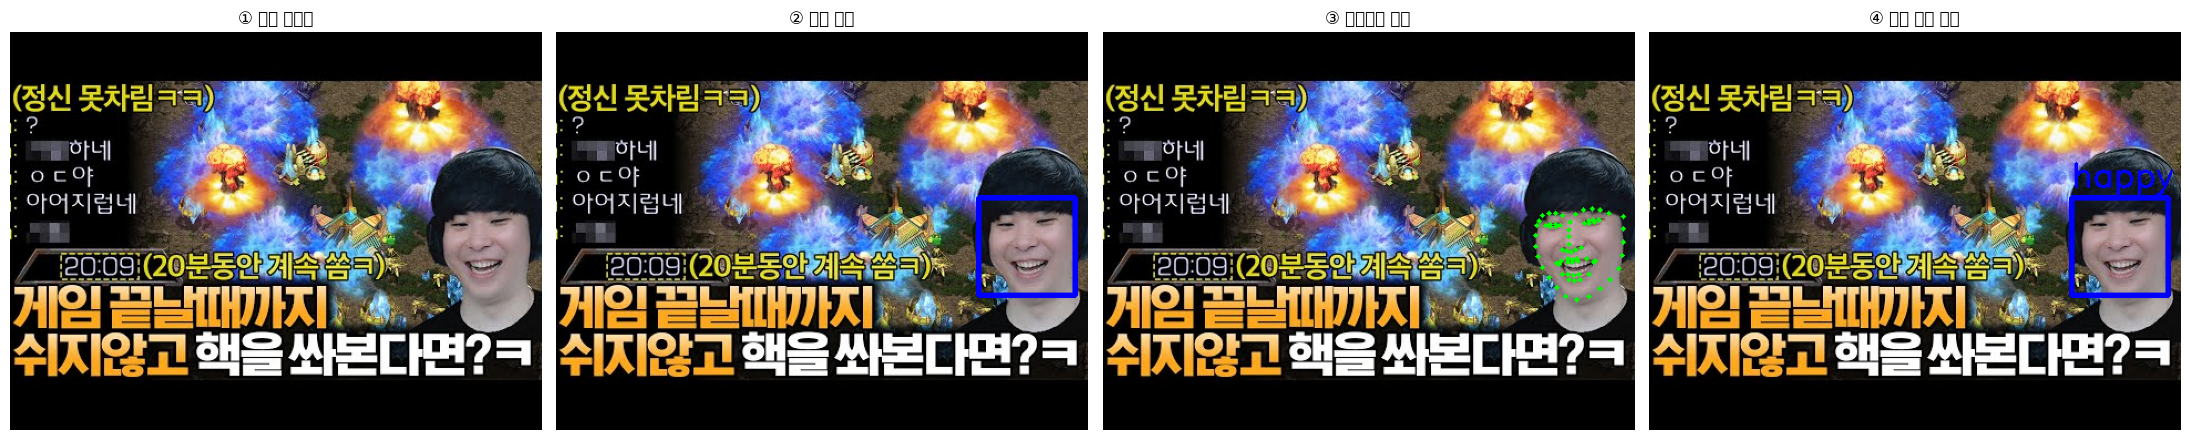

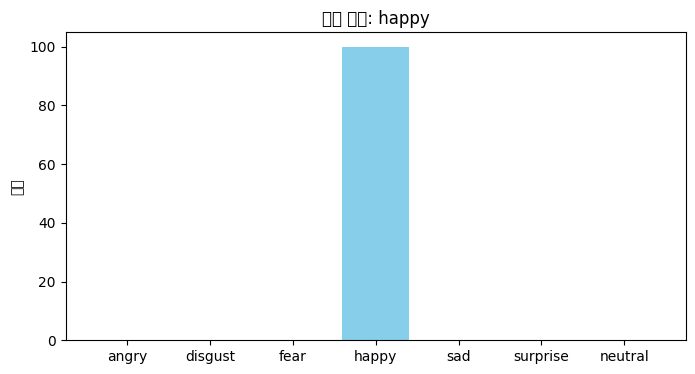

In [1]:
# 필요한 라이브러리 설치
!pip install easyocr deepface opencv-python-headless dlib

import cv2
import numpy as np
from PIL import Image, ImageDraw
import easyocr
from deepface import DeepFace
import matplotlib.pyplot as plt
import requests
import dlib
import os

# 1. 이미지 URL 입력
img_url = 'https://i.ytimg.com/vi/KLLE8lXV-jA/hqdefault.jpg'  # 원하는 이미지 URL

# 2. 이미지 다운로드 및 로드
response = requests.get(img_url)
image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')
img_array = np.array(image)
img_cv = cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR)

# 3. 얼굴 검출(dlib)
detector = dlib.get_frontal_face_detector()
gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
faces = detector(gray)

# 4. 랜드마크 모델 다운로드 및 로드 (최초 1회만)
if not os.path.exists('shape_predictor_68_face_landmarks.dat'):
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
    !bzip2 -d shape_predictor_68_face_landmarks.dat.bz2
predictor = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')

# 5. DeepFace 감정 분석
try:
    analysis = DeepFace.analyze(img_array, actions=['emotion'], enforce_detection=False)
    if isinstance(analysis, list):
        analysis = analysis[0]
    dominant_emotion = analysis['dominant_emotion']
    emotion_scores = analysis['emotion']
except Exception as e:
    dominant_emotion = 'unknown'
    emotion_scores = {}

# 6. 단계별 시각화
fig, axes = plt.subplots(1, 4, figsize=(22,6))

# (1) 원본 이미지
axes[0].imshow(image)
axes[0].set_title('① 입력 이미지')
axes[0].axis('off')

# (2) 얼굴 검출
img_facebox = img_cv.copy()
for face in faces:
    x, y, w, h = face.left(), face.top(), face.width(), face.height()
    cv2.rectangle(img_facebox, (x, y), (x+w, y+h), (255,0,0), 3)
axes[1].imshow(cv2.cvtColor(img_facebox, cv2.COLOR_BGR2RGB))
axes[1].set_title('② 얼굴 검출')
axes[1].axis('off')

# (3) 랜드마크 표시
img_landmarks = img_cv.copy()
for face in faces:
    landmarks = predictor(gray, face)
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        cv2.circle(img_landmarks, (x, y), 2, (0,255,0), -1)
axes[2].imshow(cv2.cvtColor(img_landmarks, cv2.COLOR_BGR2RGB))
axes[2].set_title('③ 랜드마크 추출')
axes[2].axis('off')

# (4) 감정 분석 결과
img_emotion = img_cv.copy()
for i, face in enumerate(faces):
    x, y, w, h = face.left(), face.top(), face.width(), face.height()
    cv2.rectangle(img_emotion, (x, y), (x+w, y+h), (255,0,0), 3)
    cv2.putText(img_emotion, dominant_emotion, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2)
axes[3].imshow(cv2.cvtColor(img_emotion, cv2.COLOR_BGR2RGB))
axes[3].set_title('④ 감정 분석 결과')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# 7. 감정 점수 바 차트
if emotion_scores:
    plt.figure(figsize=(8,4))
    plt.bar(emotion_scores.keys(), emotion_scores.values(), color='skyblue')
    plt.title(f"주요 감정: {dominant_emotion}")
    plt.ylabel('점수')
    plt.show()


In [2]:
!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,510 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126111 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new ca